In [1]:
from google.colab import drive
import pandas as pd
import os

# 1. Montar o Drive (Siga as instruções na tela para autorizar)
drive.mount('/content/drive')

# 2. Definir o caminho exato da sua pasta
# Note que o nome DADOS_CANNOLI deve estar igual ao seu print
caminho = '/content/drive/MyDrive/DADOS_CANNOLI/'

# 3. Carregar os 7 arquivos com os nomes exatos do seu print
# Atenção às extensões .CSV e .csv
df_campaign = pd.read_csv(caminho + 'CAMPAIGN.CSV')
df_conv = pd.read_csv(caminho + 'CAMPAIGNxORDER.CSV')
df_customer = pd.read_csv(caminho + 'CUSTOMER.CSV')
df_address = pd.read_csv(caminho + 'CUSTOMERADDRESS.CSV')
df_stores = pd.read_csv(caminho + 'STORE.csv')
df_orders = pd.read_csv(caminho + 'STOREORDER.csv')
df_templates = pd.read_csv(caminho + 'TEMPLATE.csv')

print(" Todos os 7 arquivos carregados com sucesso!")

# 4. Mostrar as primeiras linhas de uma tabela para testar
df_orders.head()

Mounted at /content/drive
 Todos os 7 arquivos carregados com sucesso!


,id,storeid,customerid,scheduledat,totalamount,subtotalamount,discountamount,taxamount,saleschannel,status,ordertype,createdat,createdby
0,6986251f-3cda-4671-acb9-8bc9646ed2a9,0d756ccf-7f47-4d8d-a2fb-aa78226a401d,3d04ea93-8ed5-4d29-b641-1a9a41e8820f,2025-08-26 20:54:25.674-03,59.90,69.90,10.0,0.00,IFOOD,16,DELIVERY,2025-08-26 20:54:25.674-03,Cannoli Hangfire
1,d9b8dc9a-d4da-4a8b-a57a-da6813074818,4bb014bb-8b1d-489a-aded-2060f3fda27e,5679bc63-7f77-450c-b089-423cf0c564c9,2025-11-29 12:51:14.187-03,114.00,114.00,0.0,0.00,CARDAPIOWEB,16,INDOOR,2025-11-29 12:51:14.187-03,Cannoli API
2,0b22d312-5271-4c2b-b75e-2579fadc759f,4bb014bb-8b1d-489a-aded-2060f3fda27e,5679bc63-7f77-450c-b089-423cf0c564c9,2025-11-14 20:52:45.347-03,83.90,83.90,0.0,0.00,CARDAPIOWEB,16,INDOOR,2025-11-14 20:52:45.347-03,Cannoli API
3,8782daec-d43b-4b23-9610-3797156391f4,0c02619d-0c57-492d-9660-dd0f357a2f0c,19cc7cf9-1dad-4f5d-8c28-e65f1fd212de,2025-11-01 10:39:32.516-03,45.54,44.55,0.0,0.99,IFOOD,16,DELIVERY,2025-11-01 10:39:32.516-03,Cannoli API
4,e4c15a26-d0ca-4a18-af1d-ae430e27cc25,0c02619d-0c57-492d-9660-dd0f357a2f0c,9b2b5739-1e9f-42cb-bddb-cd4f150ec9e2,2025-11-14 21:21:44.201-03,49.99,59.00,10.0,0.99,IFOOD,16,DELIVERY,2025-11-14 21:21:44.201-03,Cannoli API


--- PIPELINE DE DADOS FINALIZADO ---
1. Total de Clientes: 160710
3. Clientes Novos (30d): 8142
5. Clientes Ativos (<=30d): 14688
6. Clientes em Alerta (30-60d): 12487
8. Clientes Sumidos (>90d): 12989
11. Ticket Médio: 57.53043862819776
12. Pedidos Baixo Ticket: 61197
13. Pedidos Alto Ticket: 11704


/tmp/ipykernel_3161/1671101152.py:92: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_vendas, x='categoria_ticket', palette='viridis')


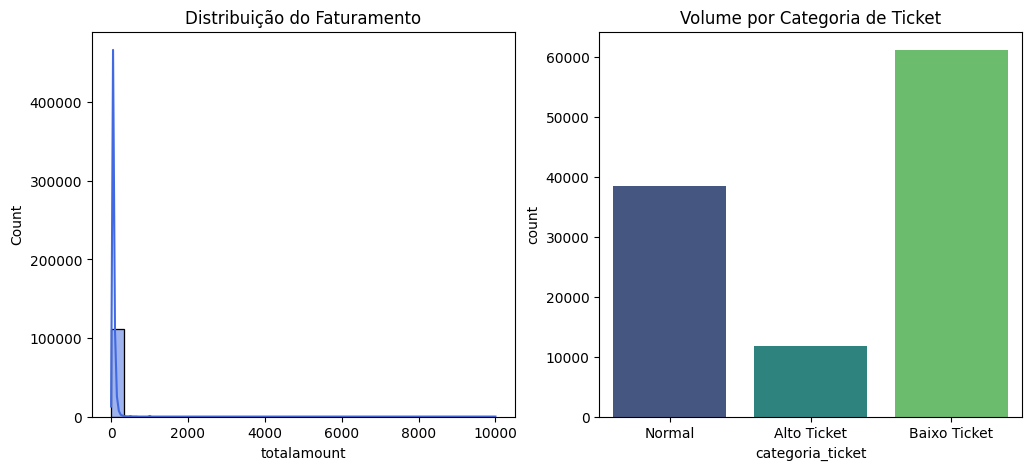

In [2]:
import pandas as pd
import numpy as np
from datetime import timedelta
import matplotlib.pyplot as plt
import seaborn as sns

# 1. CARGA DOS 7 ARQUIVOS (Via Google Drive)
caminho = '/content/drive/MyDrive/DADOS_CANNOLI/'
df_campaign = pd.read_csv(caminho + 'CAMPAIGN.CSV')
df_conv = pd.read_csv(caminho + 'CAMPAIGNxORDER.CSV')
df_customer = pd.read_csv(caminho + 'CUSTOMER.CSV')
df_address = pd.read_csv(caminho + 'CUSTOMERADDRESS.CSV')
df_stores = pd.read_csv(caminho + 'STORE.csv')
df_orders = pd.read_csv(caminho + 'STOREORDER.csv')
df_templates = pd.read_csv(caminho + 'TEMPLATE.csv')

# ==========================================
# 2. TRATAMENTO E LIMPEZA (Data Cleaning)
# ==========================================

# A. Corrigindo o erro de data (ISO8601) e removendo fuso horário
df_orders['createdat'] = pd.to_datetime(df_orders['createdat'], format='ISO8601', errors='coerce').dt.tz_localize(None)

# B. Removendo Pedidos com Valor Nulo ou Zero (Não contam para Faturamento)
df_orders = df_orders.dropna(subset=['totalamount', 'customerid'])
df_orders = df_orders[df_orders['totalamount'] > 0]

# C. Removendo Duplicatas (Garantindo integridade)
df_orders = df_orders.drop_duplicates(subset=['id'])

# D. Padronização de IDs (Garantindo que todos sejam Strings para o Merge)
df_orders['customerid'] = df_orders['customerid'].astype(str)
df_customer['id'] = df_customer['id'].astype(str)
df_orders['storeid'] = df_orders['storeid'].astype(str)
df_stores['id'] = df_stores['id'].astype(str)

# ==========================================
# 3. TRANSFORMAÇÃO E REGRAS DE NEGÓCIO
# ==========================================

# A. Aplicando o Filtro de Status de Vendas Reais (Regra enviada: 1, 15, 16, 33, 34, 35, 37, 38)
status_validos = [1, 15, 16, 33, 34, 35, 37, 38]
df_vendas = df_orders[df_orders['status'].isin(status_validos)].copy()

# B. Criando Colunas de Faixa de Ticket (KPI 12 e 13)
df_vendas['categoria_ticket'] = 'Normal'
df_vendas.loc[df_vendas['totalamount'] < 50, 'categoria_ticket'] = 'Baixo Ticket'
df_vendas.loc[df_vendas['totalamount'] > 100, 'categoria_ticket'] = 'Alto Ticket'

# C. Integrando as tabelas (Merge) para saber a Cidade e o Nome da Loja
df_master = pd.merge(df_vendas, df_stores[['id', 'name', 'city']], left_on='storeid', right_on='id', how='left')

# ==========================================
# 4. CÁLCULO DOS 13 INDICADORES DE CRM
# ==========================================
hoje = df_vendas['createdat'].max()

crm = df_vendas.groupby('customerid').agg(
    total_compras=('id', 'count'),
    primeira_compra=('createdat', 'min'),
    ultima_compra=('createdat', 'max'),
    gasto_total=('totalamount', 'sum')
).reset_index()

crm['dias_inatividade'] = (hoje - crm['ultima_compra']).dt.days

# Dicionário Final de Indicadores
resultados_kpi = {
    "1. Total de Clientes": len(df_customer),
    "3. Clientes Novos (30d)": len(crm[crm['primeira_compra'] >= (hoje - timedelta(days=30))]),
    "5. Clientes Ativos (<=30d)": len(crm[crm['dias_inatividade'] <= 30]),
    "6. Clientes em Alerta (30-60d)": len(crm[(crm['dias_inatividade'] > 30) & (crm['dias_inatividade'] <= 60)]),
    "8. Clientes Sumidos (>90d)": len(crm[crm['dias_inatividade'] > 90]),
    "11. Ticket Médio": df_vendas['totalamount'].mean(),
    "12. Pedidos Baixo Ticket": (df_vendas['categoria_ticket'] == 'Baixo Ticket').sum(),
    "13. Pedidos Alto Ticket": (df_vendas['categoria_ticket'] == 'Alto Ticket').sum()
}

print("--- PIPELINE DE DADOS FINALIZADO ---")
for k, v in resultados_kpi.items():
    print(f"{k}: {v}")

# ==========================================
# 5. GRÁFICOS (Estatística Descritiva)
# ==========================================
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df_vendas['totalamount'], bins=30, color='royalblue', kde=True)
plt.title('Distribuição do Faturamento')

plt.subplot(1, 2, 2)
sns.countplot(data=df_vendas, x='categoria_ticket', palette='viridis')
plt.title('Volume por Categoria de Ticket')
plt.show()

=== RELATÓRIO DE KPIs FINALIZADO ===
Total Clientes Base: 160710
Clientes Ativos (30d): 14697
Clientes Alerta (30-60d): 12489
Clientes Sumidos (>90d): 12990
Ticket Médio: 57.39073532558535


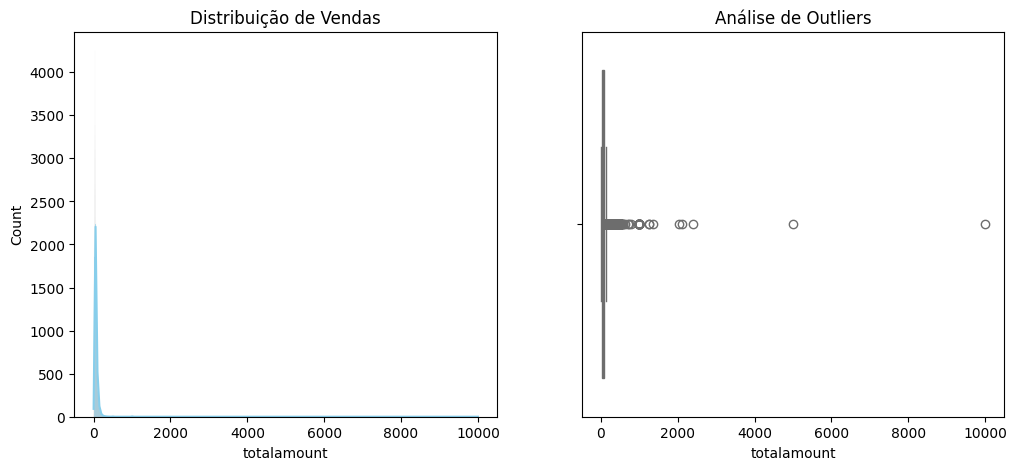

In [3]:
import pandas as pd
from datetime import timedelta
import matplotlib.pyplot as plt
import seaborn as sns

# 1. CARGA (Ajustado para os nomes do seu print)
caminho = '/content/drive/MyDrive/DADOS_CANNOLI/'
df_camp = pd.read_csv(caminho + 'CAMPAIGN.CSV')
df_conv = pd.read_csv(caminho + 'CAMPAIGNxORDER.CSV')
df_cust = pd.read_csv(caminho + 'CUSTOMER.CSV')
df_orde = pd.read_csv(caminho + 'STOREORDER.csv')
df_stor = pd.read_csv(caminho + 'STORE.csv')

# 2. LIMPEZA E PADRONIZAÇÃO
df_orde['createdat'] = pd.to_datetime(df_orde['createdat'], format='ISO8601', errors='coerce').dt.tz_localize(None)
hoje = df_orde['createdat'].max()

# Filtro de Status Válidos
status_validos = [1, 15, 16, 33, 34, 35, 37, 38]
df_vendas = df_orde[df_orde['status'].isin(status_validos)].copy()

# 3. INTEGRAÇÃO (MERGE) - Lógica de Proteção contra KeyError
df_master = pd.merge(df_vendas, df_stor[['id', 'name', 'city']], left_on='storeid', right_on='id', how='left')

# 4. CÁLCULO DOS INDICADORES DE CRM
crm = df_vendas.groupby('customerid').agg(
    qtd_pedidos=('id', 'count'),
    ultima_compra=('createdat', 'max'),
    primeira_compra=('createdat', 'min'),
    valor_total=('totalamount', 'sum')
).reset_index()

crm['dias_longe'] = (hoje - crm['ultima_compra']).dt.days

# Dicionário de Resultados
kpis = {
    "Total Clientes Base": len(df_cust),
    "Clientes Ativos (30d)": len(crm[crm['dias_longe'] <= 30]),
    "Clientes Alerta (30-60d)": len(crm[(crm['dias_longe'] > 30) & (crm['dias_longe'] <= 60)]),
    "Clientes Sumidos (>90d)": len(crm[crm['dias_longe'] > 90]),
    "Ticket Médio": df_vendas['totalamount'].mean()
}

print("=== RELATÓRIO DE KPIs FINALIZADO ===")
for k, v in kpis.items():
    print(f"{k}: {v}")

# 5. GRÁFICOS PARA O PDF
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df_vendas['totalamount'], kde=True, color='skyblue')
plt.title('Distribuição de Vendas')

plt.subplot(1, 2, 2)
sns.boxplot(x=df_vendas['totalamount'], color='salmon')
plt.title('Análise de Outliers')
plt.show()

In [28]:
# Verifica se existem clientes nos pedidos que NÃO estão na tabela de clientes
clientes_orfãos = df_orders[~df_orders['customerid'].isin(df_customer['id'])]

if clientes_orfãos.empty:
    print("✅ Integridade Confirmada: Todos os clientes dos pedidos existem na base de clientes.")
else:
    print(f"⚠️ Atenção: Existem {clientes_orfãos['customerid'].nunique()} IDs de clientes nos pedidos sem cadastro.")

⚠️ Atenção: Existem 18284 IDs de clientes nos pedidos sem cadastro.


In [4]:
import pandas as pd
from datetime import timedelta

# 1. CARGA SEGURA
caminho = '/content/drive/MyDrive/DADOS_CANNOLI/'
df_orde = pd.read_csv(caminho + 'STOREORDER.csv')
df_cust = pd.read_csv(caminho + 'CUSTOMER.CSV')
df_stor = pd.read_csv(caminho + 'STORE.csv')

# 2. LIMPEZA E UNIFORMIZAÇÃO (Item 5 da sua Entrega)
# Tratando as datas que deram erro antes
df_orde['createdat'] = pd.to_datetime(df_orde['createdat'], format='ISO8601', errors='coerce').dt.tz_localize(None)
hoje = df_orde['createdat'].max()

# Filtro de Status (Regra de Negócio)
status_validos = [1, 15, 16, 33, 34, 35, 37, 38]
df_vendas = df_orde[df_orde['status'].isin(status_validos)].copy()

# 3. INTEGRAÇÃO DOS DADOS (Item 7 da sua Entrega)
# Unindo Pedidos com Lojas para ter a Cidade
df_master = pd.merge(df_vendas, df_stor[['id', 'name', 'city']], left_on='storeid', right_on='id', how='left')

# 4. DERIVAÇÃO DE DADOS (Item 6 da sua Entrega)
crm = df_vendas.groupby('customerid').agg(
    total_pedidos=('id', 'count'),
    ultima_compra=('createdat', 'max'),
    ticket_medio=('totalamount', 'mean')
).reset_index()

crm['dias_inatividade'] = (hoje - crm['ultima_compra']).dt.days

# RESULTADOS PARA O PDF
print(f"Relatório Gerado em: {hoje}")
print(f"Total de Pedidos Válidos: {len(df_vendas)}")
print(f"Ticket Médio Geral: R$ {df_vendas['totalamount'].mean():.2f}")
print(f"Clientes Ativos (30d): {len(crm[crm['dias_inatividade'] <= 30])}")

Relatório Gerado em: 2026-01-30 17:50:12.239000
Total de Pedidos Válidos: 111599
Ticket Médio Geral: R$ 57.39
Clientes Ativos (30d): 14697


✅ Todos os 7 arquivos foram coletados com sucesso.

--- RESULTADOS DA EXPLORAÇÃO ---
Ticket Médio: R$ 58.90
Clientes Ativos (30d): 14697


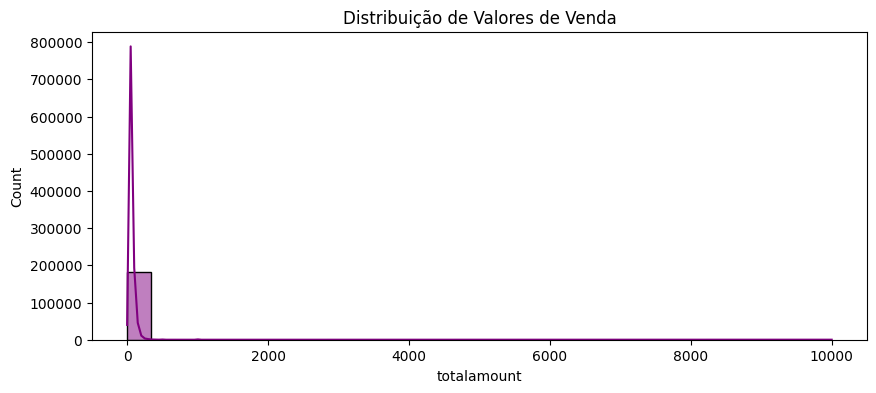

In [5]:
import pandas as pd
import numpy as np
import seaborn as sns  # Correção aqui
import matplotlib.pyplot as plt
from datetime import timedelta

# ---------------------------------------------------------
# 1. IDENTIFICAR E COLETAR (Carga dos 7 arquivos)
# ---------------------------------------------------------
caminho = '/content/drive/MyDrive/DADOS_CANNOLI/'

df_camp = pd.read_csv(caminho + 'CAMPAIGN.CSV')
df_conv = pd.read_csv(caminho + 'CAMPAIGNxORDER.CSV')
df_cust = pd.read_csv(caminho + 'CUSTOMER.CSV')
df_addr = pd.read_csv(caminho + 'CUSTOMERADDRESS.CSV')
df_stor = pd.read_csv(caminho + 'STORE.csv')
df_orde = pd.read_csv(caminho + 'STOREORDER.csv')
df_temp = pd.read_csv(caminho + 'TEMPLATE.csv')

print("✅ Todos os 7 arquivos foram coletados com sucesso.")

# ---------------------------------------------------------
# 2. LIMPAR / UNIFORMIZAR (Tratamento de tipos e datas)
# ---------------------------------------------------------
# Padronizando IDs para String para evitar erros no merge
for df in [df_camp, df_conv, df_cust, df_addr, df_stor, df_orde, df_temp]:
    for col in ['id', 'customerid', 'storeid', 'order_id', 'campaignid', 'segmentid']:
        if col in df.columns:
            df[col] = df[col].astype(str)

# Tratando datas (ISO8601) e removendo timezone
df_orde['createdat'] = pd.to_datetime(df_orde['createdat'], format='ISO8601', errors='coerce').dt.tz_localize(None)
hoje = df_orde['createdat'].max()

# Selecionar Dados: Filtro de Status de Venda Real
status_validos = [1, 15, 16, 33, 34, 35, 37, 38]
df_vendas = df_orde[df_orde['status'].isin(status_validos)].copy()

# ---------------------------------------------------------
# 3. INTEGRAR OS DADOS (Joins entre as tabelas)
# ---------------------------------------------------------
# Integrando Pedidos + Lojas + Clientes + Conversões
df_m = pd.merge(df_vendas, df_stor[['id', 'city', 'name']], left_on='storeid', right_on='id', how='left', suffixes=('', '_loja'))
df_m = pd.merge(df_m, df_cust[['id', 'name']], left_on='customerid', right_on='id', how='left', suffixes=('', '_cliente'))
df_m = pd.merge(df_m, df_conv[['order_id', 'campaignid']], left_on='id', right_on='order_id', how='left')

# ---------------------------------------------------------
# 4. DERIVAR DADOS (Criação de novas métricas)
# ---------------------------------------------------------
# Recência (Dias desde a última compra por cliente)
crm = df_vendas.groupby('customerid').agg(
    ult_compra=('createdat', 'max'),
    total_gasto=('totalamount', 'sum'),
    qtd_pedidos=('id', 'count')
).reset_index()

crm['dias_inatividade'] = (hoje - crm['ult_compra']).dt.days

# Derivando Categoria de Ticket
df_m['cat_ticket'] = pd.cut(df_m['totalamount'], bins=[0, 50, 100, 99999], labels=['Baixo', 'Médio', 'Alto'])

# ---------------------------------------------------------
# 5. EXPLORAR E FORMATAR (KPIs e Gráficos)
# ---------------------------------------------------------
print("\n--- RESULTADOS DA EXPLORAÇÃO ---")
print(f"Ticket Médio: R$ {df_m['totalamount'].mean():.2f}")
print(f"Clientes Ativos (30d): {len(crm[crm['dias_inatividade'] <= 30])}")

# Formatar: Exportar dataframe final para CSV (opcional)
df_m.to_csv('base_consolidada_entrega1.csv', index=False)

# Visualização
plt.figure(figsize=(10, 4))
sns.histplot(df_m['totalamount'], bins=30, kde=True, color='purple')
plt.title('Distribuição de Valores de Venda')
plt.show()

In [6]:
# Lista de todos os seus DataFrames
meus_datasets = {
    'Campanha': df_camp,
    'Conversao': df_conv,
    'Cliente': df_cust,
    'Endereco': df_addr,
    'Loja': df_stor,
    'Pedido': df_orde,
    'Template': df_temp
}

# Dicionário de tradução mestre
traducao_geral = {
    'segmentid': 'id_segmento',
    'templateid': 'id_template',
    'storeid': 'id_loja',
    'customerid': 'id_cliente',
    'order_id': 'id_pedido',
    'campaignid': 'id_campanha',
    'totalamount': 'valor_total',
    'createdat': 'data_criacao',
    'name': 'nome',
    'description': 'descricao',
    'type': 'tipo',
    'status': 'status_codigo',
    'city': 'cidade',
    'state': 'estado',
    'neighborhood': 'bairro',
    'zipcode': 'cep',
    'gender': 'genero',
    'dateofbirth': 'data_nascimento'
}

# Aplicando a tradução em todos os 7 de uma vez
for nome, df in meus_datasets.items():
    df.rename(columns=traducao_geral, inplace=True)
    print(f"✅ Arquivo '{nome}' traduzido e uniformizado.")

✅ Arquivo 'Campanha' traduzido e uniformizado.
✅ Arquivo 'Conversao' traduzido e uniformizado.
✅ Arquivo 'Cliente' traduzido e uniformizado.
✅ Arquivo 'Endereco' traduzido e uniformizado.
✅ Arquivo 'Loja' traduzido e uniformizado.
✅ Arquivo 'Pedido' traduzido e uniformizado.
✅ Arquivo 'Template' traduzido e uniformizado.


In [7]:
# Criando uma lista com os nomes traduzidos e os respectivos dataframes
inspecao = {
    "Campanhas": df_camp,
    "Conversões": df_conv,
    "Clientes": df_cust,
    "Endereços": df_addr,
    "Lojas": df_stor,
    "Pedidos": df_orde,
    "Templates": df_temp
}

for nome, df in inspecao.items():
    print(f"\n{'='*20} ARQUIVO: {nome.upper()} {'='*20}")

    # 1. Mostra as primeiras 3 linhas para ver os dados traduzidos
    display(df.head(3))

    # 2. Mostra o tipo de dados (se as datas são datetime e valores são float)
    print(f"\nResumo técnico de '{nome}':")
    df.info()


==================== ARQUIVO: CAMPANHAS ====================


,id_segmento,id_template,id_loja,nome,descricao,tipo,statusend,data_criacao,id_cliente,sendat
0,9e2c65a1-05bc-4896-902f-e3bec38ca1b9,cfbb9c54-6131-4ede-b394-6cfd2b5b407e,01ac4ec3-f7e0-451d-ab31-2db1799816ca,Promover almoço,Campanha para promover almoço,1,2,2025-07-18 21:24:02.83-03,d6eb7af9-9071-4342-93e6-b2b559538288,2025-08-01 11:15:53.997-03
1,d7f18a0d-7bcb-49c0-b44d-86dce7d12578,0807ac90-8501-4faf-abaf-f81c4bb8451d,8cc52834-d064-4c6a-8e08-8f33d4811872,COMBO FAMILIA,COMBO FAMILIA,1,2,2025-12-02 19:08:22.588-03,7bb6b09c-93a8-4702-bd15-07d1a29ea119,2025-12-18 18:38:19.002-03
2,8cfa67af-83af-4c2a-b61e-4ad80be6e261,59905afd-f186-4d77-81c2-aa2e2820b7f3,0d860437-8f2f-4437-a866-811bd07ac367,Clientes com 1 pedido,NaN,1,2,2025-12-01 22:24:24.701-03,4ea8e93c-071c-4e36-a04a-040c070fef38,2026-01-18 20:03:39.257-03



Resumo técnico de 'Campanhas':
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 56461 entries, 0 to 56460
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   id_segmento   56461 non-null  object
 1   id_template   55169 non-null  object
 2   id_loja       56461 non-null  object
 3   nome          56461 non-null  object
 4   descricao     45282 non-null  object
 5   tipo          56461 non-null  int64 
 6   statusend     56461 non-null  int64 
 7   data_criacao  56461 non-null  object
 8   id_cliente    56461 non-null  object
 9   sendat        56461 non-null  object
dtypes: int64(2), object(8)
memory usage: 4.3+ MB

==================== ARQUIVO: CONVERSÕES ====================


,id_campanha,message_id,sent_at,status_codigo,order_at,id_loja,id_cliente,id_pedido,valor_total
0,cfb4c5a3-bbef-49b2-a9b4-36a36647a903,6a24300f-79c8-4413-95d5-f36c553ddf73,2026-01-10 18:38:10.033-03,2,2025-11-14 21:21:44.201-03,0c02619d-0c57-492d-9660-dd0f357a2f0c,9b2b5739-1e9f-42cb-bddb-cd4f150ec9e2,e4c15a26-d0ca-4a18-af1d-ae430e27cc25,49.99
1,495c6a94-9cca-4f58-9353-fac46ffd49a2,7de7cc4d-fe29-445c-b980-6ff8af83eb66,2025-11-15 15:35:27.382-03,2,2025-11-14 21:21:44.201-03,0c02619d-0c57-492d-9660-dd0f357a2f0c,9b2b5739-1e9f-42cb-bddb-cd4f150ec9e2,e4c15a26-d0ca-4a18-af1d-ae430e27cc25,49.99
2,1412e88b-556f-4bb6-8f55-625d783c597c,fb3a3377-b6cd-478d-9844-c8fc1f7f7911,2025-12-13 19:55:14.038-03,2,2025-11-14 21:21:44.201-03,0c02619d-0c57-492d-9660-dd0f357a2f0c,9b2b5739-1e9f-42cb-bddb-cd4f150ec9e2,e4c15a26-d0ca-4a18-af1d-ae430e27cc25,49.99



Resumo técnico de 'Conversões':
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 95284 entries, 0 to 95283
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id_campanha    95284 non-null  object 
 1   message_id     95284 non-null  object 
 2   sent_at        95284 non-null  object 
 3   status_codigo  95284 non-null  int64  
 4   order_at       95284 non-null  object 
 5   id_loja        95284 non-null  object 
 6   id_cliente     95284 non-null  object 
 7   id_pedido      95284 non-null  object 
 8   valor_total    95284 non-null  float64
dtypes: float64(1), int64(1), object(7)
memory usage: 6.5+ MB

==================== ARQUIVO: CLIENTES ====================


...


Resumo técnico de 'Lojas':
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77 entries, 0 to 76
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             77 non-null     object 
 1   nome           77 non-null     object 
 2   complement     13 non-null     object 
 3   bairro         0 non-null      float64
 4   cidade         5 non-null      object 
 5   estado         5 non-null      object 
 6   cep            23 non-null     float64
 7   status_codigo  77 non-null     int64  
 8   data_criacao   77 non-null     object 
dtypes: float64(2), int64(1), object(6)
memory usage: 5.5+ KB

==================== ARQUIVO: PEDIDOS ====================


,id,id_loja,id_cliente,scheduledat,valor_total,subtotalamount,discountamount,taxamount,saleschannel,status_codigo,ordertype,data_criacao,createdby
0,6986251f-3cda-4671-acb9-8bc9646ed2a9,0d756ccf-7f47-4d8d-a2fb-aa78226a401d,3d04ea93-8ed5-4d29-b641-1a9a41e8820f,2025-08-26 20:54:25.674-03,59.9,69.9,10.0,0.0,IFOOD,16,DELIVERY,2025-08-26 20:54:25.674,Cannoli Hangfire
1,d9b8dc9a-d4da-4a8b-a57a-da6813074818,4bb014bb-8b1d-489a-aded-2060f3fda27e,5679bc63-7f77-450c-b089-423cf0c564c9,2025-11-29 12:51:14.187-03,114.0,114.0,0.0,0.0,CARDAPIOWEB,16,INDOOR,2025-11-29 12:51:14.187,Cannoli API
2,0b22d312-5271-4c2b-b75e-2579fadc759f,4bb014bb-8b1d-489a-aded-2060f3fda27e,5679bc63-7f77-450c-b089-423cf0c564c9,2025-11-14 20:52:45.347-03,83.9,83.9,0.0,0.0,CARDAPIOWEB,16,INDOOR,2025-11-14 20:52:45.347,Cannoli API



Resumo técnico de 'Pedidos':
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 118936 entries, 0 to 118935
Data columns (total 13 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   id              118936 non-null  object        
 1   id_loja         118936 non-null  object        
 2   id_cliente      118936 non-null  object        
 3   scheduledat     118936 non-null  object        
 4   valor_total     118936 non-null  float64       
 5   subtotalamount  118936 non-null  float64       
 6   discountamount  118936 non-null  float64       
 7   taxamount       118936 non-null  float64       
 8   saleschannel    118936 non-null  object        
 9   status_codigo   118936 non-null  int64         
 10  ordertype       118936 non-null  object        
 11  data_criacao    118936 non-null  datetime64[ns]
 12  createdby       118936 non-null  object        
dtypes: datetime64[ns](1), float64(4), int64(1), object(7)
memor

,id,id_loja,nome,descricao,data_criacao,createdby
0,d1650bf1-b5b9-4b71-aeef-4e88d0b8033b,9b4bf8bf-2f5c-4680-afe1-8014b371d518,10% de bonificação Chá Blend,10% de bonificação Chá Blend,2025-10-24 09:57:52.522-03,Vida Leve - Compras
1,c62d7f8b-9df0-401d-9899-3b1710159478,9b4bf8bf-2f5c-4680-afe1-8014b371d518,Template - Promoções de Reposição,Template - Promoções de Reposição,2025-10-24 10:11:22.084-03,Vida Leve - Compras
2,d89cc9cf-ca1a-45c8-a694-76b6c4ebded7,97674906-e4bb-47cf-9d9e-4ebd7f4ee919,Convite Ensaio - Outubro25,Convite Ensaio - Outubro25,2025-10-25 21:56:31.378-03,Admin



Resumo técnico de 'Templates':
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 348 entries, 0 to 347
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   id            348 non-null    object
 1   id_loja       348 non-null    object
 2   nome          348 non-null    object
 3   descricao     273 non-null    object
 4   data_criacao  348 non-null    object
 5   createdby     348 non-null    object
dtypes: object(6)
memory usage: 16.4+ KB


In [8]:
tradução_extra = {
    'subtotalamount': 'valor_subtotal',
    'discountamount': 'valor_desconto',
    'taxamount': 'valor_taxa',
    'saleschannel': 'canal_venda',
    'ordertype': 'tipo_pedido',
    'createdby': 'criado_por',
    'scheduledat': 'data_agendamento'
}

# Aplicar ao DataFrame de Pedidos
df_orde = df_orde.rename(columns=tradução_extra)

In [9]:
# Salvando os arquivos principais já formatados
df_orde.to_csv('pedidos_limpo.csv', index=False)
df_cust.to_csv('clientes_limpo.csv', index=False)
df_stor.to_csv('lojas_limpo.csv', index=False)

print("🚀 Arquivos formatados e salvos para a Entrega 2!")

🚀 Arquivos formatados e salvos para a Entrega 2!


In [10]:
# Lista dos seus dataframes atualizados
datasets = {
    "Campanhas": df_camp,
    "Conversões": df_conv,
    "Clientes": df_cust,
    "Endereços": df_addr,
    "Lojas": df_stor,
    "Pedidos": df_orde,
    "Templates": df_temp
}

print("🔍 VERIFICAÇÃO DE NOMES DE COLUNAS\n")
for nome, df in datasets.items():
    print(f"📄 Arquivo: {nome}")
    print(f"   Colunas: {df.columns.tolist()}")
    print("-" * 30)

🔍 VERIFICAÇÃO DE NOMES DE COLUNAS

📄 Arquivo: Campanhas
   Colunas: ['id_segmento', 'id_template', 'id_loja', 'nome', 'descricao', 'tipo', 'statusend', 'data_criacao', 'id_cliente', 'sendat']
------------------------------
📄 Arquivo: Conversões
   Colunas: ['id_campanha', 'message_id', 'sent_at', 'status_codigo', 'order_at', 'id_loja', 'id_cliente', 'id_pedido', 'valor_total']
------------------------------
📄 Arquivo: Clientes
   Colunas: ['id', 'nome', 'genero', 'data_nascimento', 'status_codigo', 'isenriched', 'enrichedat', 'enrichedby', 'data_criacao', 'updatedat', 'updatedby', 'birthmonth', 'birthday']
------------------------------
📄 Arquivo: Endereços
   Colunas: ['id', 'id_cliente', 'bairro', 'cidade', 'estado', 'cep', 'status_codigo']
------------------------------
📄 Arquivo: Lojas
   Colunas: ['id', 'nome', 'complement', 'bairro', 'cidade', 'estado', 'cep', 'status_codigo', 'data_criacao']
------------------------------
📄 Arquivo: Pedidos
   Colunas: ['id', 'id_loja', 'id_clie

In [11]:
# Dicionário mestre definitivo para matar o inglês de vez
traducao_final = {
    # Campanhas / Conversões
    'statusend': 'status_fim',
    'sendat': 'data_envio',
    'sent_at': 'data_envio',
    'message_id': 'id_mensagem',
    'order_at': 'data_pedido',

    # Clientes
    'isenriched': 'enriquecido',
    'enrichedat': 'data_enriquecimento',
    'enrichedby': 'enriquecido_por',
    'updatedat': 'data_atualizacao',
    'updatedby': 'atualizado_por',
    'birthmonth': 'mes_nascimento',
    'birthday': 'dia_nascimento',

    # Lojas / Outros
    'complement': 'complemento',
    'createdby': 'criado_por'
}

# Aplicando em todos os DataFrames
df_camp.rename(columns=traducao_final, inplace=True)
df_conv.rename(columns=traducao_final, inplace=True)
df_cust.rename(columns=traducao_final, inplace=True)
df_addr.rename(columns=traducao_final, inplace=True)
df_stor.rename(columns=traducao_final, inplace=True)
df_orde.rename(columns=traducao_final, inplace=True)
df_temp.rename(columns=traducao_final, inplace=True)

print("🚀 Limpeza completa! Agora todos os 7 arquivos falam português.")

🚀 Limpeza completa! Agora todos os 7 arquivos falam português.


In [12]:
# Lista dos seus dataframes
datasets = {
    "Campanhas": df_camp, "Conversões": df_conv, "Clientes": df_cust,
    "Endereços": df_addr, "Lojas": df_stor, "Pedidos": df_orde, "Templates": df_temp
}

for nome, df in datasets.items():
    print(f"\n{'='*30}\nDIAGNÓSTICO: {nome.upper()}\n{'='*30}")

    # Verifica tipos de dados e valores nulos
    print(df.info())

    # Mostra estatísticas básicas (média, min, max) para colunas numéricas
    if not df.select_dtypes(include=['number']).empty:
        print("\nResumo Estatístico:")
        display(df.describe())

    # Verifica se há dados duplicados
    duplicados = df.duplicated().sum()
    print(f"\nLinhas duplicadas: {duplicados}")


DIAGNÓSTICO: CAMPANHAS
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 56461 entries, 0 to 56460
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   id_segmento   56461 non-null  object
 1   id_template   55169 non-null  object
 2   id_loja       56461 non-null  object
 3   nome          56461 non-null  object
 4   descricao     45282 non-null  object
 5   tipo          56461 non-null  int64 
 6   status_fim    56461 non-null  int64 
 7   data_criacao  56461 non-null  object
 8   id_cliente    56461 non-null  object
 9   data_envio    56461 non-null  object
dtypes: int64(2), object(8)
memory usage: 4.3+ MB
None

Resumo Estatístico:


,tipo,status_fim
count,56461.000000,56461.000000
mean,1.013124,2.435522
std,0.130754,1.139371
min,1.000000,1.000000
25%,1.000000,2.000000
50%,1.000000,2.000000
75%,1.000000,2.000000
max,3.000000,7.000000



Linhas duplicadas: 14

DIAGNÓSTICO: CONVERSÕES
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 95284 entries, 0 to 95283
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id_campanha    95284 non-null  object 
 1   id_mensagem    95284 non-null  object 
 2   data_envio     95284 non-null  object 
 3   status_codigo  95284 non-null  int64  
 4   data_pedido    95284 non-null  object 
 5   id_loja        95284 non-null  object 
 6   id_cliente     95284 non-null  object 
 7   id_pedido      95284 non-null  object 
 8   valor_total    95284 non-null  float64
dtypes: float64(1), int64(1), object(7)
memory usage: 6.5+ MB
None

Resumo Estatístico:


,status_codigo,valor_total
count,95284.000000,95284.000000
mean,2.467739,61.332265
std,0.846584,89.949725
min,2.000000,0.000000
25%,2.000000,35.000000
50%,2.000000,51.890000
75%,2.000000,73.800000
max,4.000000,10000.000000



Linhas duplicadas: 0

DIAGNÓSTICO: CLIENTES
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 160710 entries, 0 to 160709
Data columns (total 13 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   id                   160710 non-null  object 
 1   nome                 160693 non-null  object 
 2   genero               100918 non-null  object 
 3   data_nascimento      8903 non-null    object 
 4   status_codigo        160710 non-null  int64  
 5   enriquecido          3637 non-null    object 
 6   data_enriquecimento  3637 non-null    object 
 7   enriquecido_por      3637 non-null    object 
 8   data_criacao         160710 non-null  object 
 9   data_atualizacao     160710 non-null  object 
 10  atualizado_por       160710 non-null  object 
 11  mes_nascimento       8903 non-null    float64
 12  dia_nascimento       8903 non-null    float64
dtypes: float64(2), int64(1), object(10)
memory usage: 15.9+ MB
None

Resumo Es

...


Linhas duplicadas: 0

DIAGNÓSTICO: LOJAS
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77 entries, 0 to 76
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             77 non-null     object 
 1   nome           77 non-null     object 
 2   complemento    13 non-null     object 
 3   bairro         0 non-null      float64
 4   cidade         5 non-null      object 
 5   estado         5 non-null      object 
 6   cep            23 non-null     float64
 7   status_codigo  77 non-null     int64  
 8   data_criacao   77 non-null     object 
dtypes: float64(2), int64(1), object(6)
memory usage: 5.5+ KB
None

Resumo Estatístico:


,bairro,cep,status_codigo
count,0.0,2.300000e+01,77.0
mean,NaN,2.649086e+07,1.0
std,NaN,3.459606e+07,0.0
min,NaN,2.201002e+06,1.0
25%,NaN,3.015000e+06,1.0
50%,NaN,4.094050e+06,1.0
75%,NaN,6.755874e+07,1.0
max,NaN,8.702012e+07,1.0



Linhas duplicadas: 0

DIAGNÓSTICO: PEDIDOS
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 118936 entries, 0 to 118935
Data columns (total 13 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   id                118936 non-null  object        
 1   id_loja           118936 non-null  object        
 2   id_cliente        118936 non-null  object        
 3   data_agendamento  118936 non-null  object        
 4   valor_total       118936 non-null  float64       
 5   valor_subtotal    118936 non-null  float64       
 6   valor_desconto    118936 non-null  float64       
 7   valor_taxa        118936 non-null  float64       
 8   canal_venda       118936 non-null  object        
 9   status_codigo     118936 non-null  int64         
 10  tipo_pedido       118936 non-null  object        
 11  data_criacao      118936 non-null  datetime64[ns]
 12  criado_por        118936 non-null  object        
dtypes: datetime64[n

,valor_total,valor_subtotal,valor_desconto,valor_taxa,status_codigo,data_criacao
count,118936.000000,118936.000000,118936.000000,118936.000000,118936.000000,118936
mean,57.327612,55.985531,5.416454,6.791507,15.395355,2025-11-04 08:29:54.569339136
min,0.000000,0.000000,0.000000,0.000000,1.000000,2025-02-12 12:14:45.908000
25%,31.890000,31.100000,0.000000,3.490000,16.000000,2025-09-23 02:49:09.855000064
50%,45.910000,44.900000,3.150000,6.980000,16.000000,2025-11-20 17:51:02.423500032
75%,69.880000,67.800000,10.000000,9.890000,16.000000,2025-12-22 21:11:28.058500096
max,10000.000000,10000.000000,368.000000,43.840000,38.000000,2026-01-30 17:50:12.239000
std,55.960722,55.422284,6.660933,4.524656,3.208949,NaN



Linhas duplicadas: 0

DIAGNÓSTICO: TEMPLATES
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 348 entries, 0 to 347
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   id            348 non-null    object
 1   id_loja       348 non-null    object
 2   nome          348 non-null    object
 3   descricao     273 non-null    object
 4   data_criacao  348 non-null    object
 5   criado_por    348 non-null    object
dtypes: object(6)
memory usage: 16.4+ KB
None

Linhas duplicadas: 0


In [13]:
# 1. Removendo duplicados em Campanhas
df_camp.drop_duplicates(inplace=True)

# 2. Convertendo TODAS as datas de uma vez
colunas_data = {
    'Campanhas': (df_camp, ['data_criacao', 'data_envio']),
    'Conversões': (df_conv, ['data_envio', 'data_pedido']),
    'Clientes': (df_cust, ['data_nascimento', 'data_criacao', 'data_atualizacao', 'data_enriquecimento']),
    'Lojas': (df_stor, ['data_criacao']),
    'Templates': (df_temp, ['data_criacao'])
}

for nome, (df, colunas) in colunas_data.items():
    for col in colunas:
        df[col] = pd.to_datetime(df[col], errors='coerce').dt.tz_localize(None)
    print(f" Datas de {nome} convertidas.")

# 3. Tratando IDs como Strings (para não somar IDs por erro)
for df in [df_camp, df_conv, df_cust, df_addr, df_stor, df_orde, df_temp]:
    if 'id' in df.columns: df['id'] = df['id'].astype(str)
    if 'id_cliente' in df.columns: df['id_cliente'] = df['id_cliente'].astype(str)

print("\n🚀 Tratamento concluído! Agora os tipos estão perfeitos para análise.")

 Datas de Campanhas convertidas.
 Datas de Conversões convertidas.
 Datas de Clientes convertidas.
 Datas de Lojas convertidas.
 Datas de Templates convertidas.

🚀 Tratamento concluído! Agora os tipos estão perfeitos para análise.


In [14]:
import pandas as pd

# Dicionário com seus DataFrames atualizados
datasets = {
    "Campanhas": df_camp, "Conversões": df_conv, "Clientes": df_cust,
    "Endereços": df_addr, "Lojas": df_stor, "Pedidos": df_orde, "Templates": df_temp
}

print("✅ INICIANDO VALIDAÇÃO DE FORMATOS PARA GRÁFICOS\n")

for nome, df in datasets.items():
    print(f"--- Arquivo: {nome} ---")

    # 1. Validação de Datas (Devem ser datetime64)
    cols_data = [c for c in df.columns if 'data' in c or 'at' in c or 'envio' in c]
    for c in cols_data:
        status = "CORRETO (datetime)" if pd.api.types.is_datetime64_any_dtype(df[c]) else "❌ ERRO (Ainda é texto/object)"
        print(f"  [Data] {c}: {status}")

    # 2. Validação de Valores Monetários (Devem ser float)
    cols_valor = [c for c in df.columns if 'valor' in c or 'amount' in c]
    for c in cols_valor:
        status = "CORRETO (float/int)" if pd.api.types.is_numeric_dtype(df[c]) else "❌ ERRO (Ainda é texto/object)"
        print(f"  [Valor] {c}: {status}")

    # 3. Validação de IDs (Devem ser object/string para não somar por erro)
    cols_id = [c for c in df.columns if 'id' in c]
    for c in cols_id:
        status = "CORRETO (string/object)" if not pd.api.types.is_numeric_dtype(df[c]) else "⚠️ ALERTA (Está como número, cuidado ao somar)"
        print(f"  [ID] {c}: {status}")

    print("-" * 40)

✅ INICIANDO VALIDAÇÃO DE FORMATOS PARA GRÁFICOS

--- Arquivo: Campanhas ---
  [Data] id_template: ❌ ERRO (Ainda é texto/object)
  [Data] status_fim: ❌ ERRO (Ainda é texto/object)
  [Data] data_criacao: CORRETO (datetime)
  [Data] data_envio: CORRETO (datetime)
  [ID] id_segmento: CORRETO (string/object)
  [ID] id_template: CORRETO (string/object)
  [ID] id_loja: CORRETO (string/object)
  [ID] id_cliente: CORRETO (string/object)
----------------------------------------
--- Arquivo: Conversões ---
  [Data] data_envio: CORRETO (datetime)
  [Data] status_codigo: ❌ ERRO (Ainda é texto/object)
  [Data] data_pedido: CORRETO (datetime)
  [Valor] valor_total: CORRETO (float/int)
  [ID] id_campanha: CORRETO (string/object)
  [ID] id_mensagem: CORRETO (string/object)
  [ID] data_pedido: CORRETO (string/object)
  [ID] id_loja: CORRETO (string/object)
  [ID] id_cliente: CORRETO (string/object)
  [ID] id_pedido: CORRETO (string/object)
----------------------------------------
--- Arquivo: Clientes -

In [15]:
# Verificação rápida de tipos para todos os arquivos
datasets = {
    "Campanhas": df_camp, "Conversões": df_conv, "Clientes": df_cust,
    "Endereços": df_addr, "Lojas": df_stor, "Pedidos": df_orde, "Templates": df_temp
}

for nome, df in datasets.items():
    print(f"\n--- Estrutura de: {nome} ---")
    print(df.dtypes)


--- Estrutura de: Campanhas ---
id_segmento             object
id_template             object
id_loja                 object
nome                    object
descricao               object
tipo                     int64
status_fim               int64
data_criacao    datetime64[ns]
id_cliente              object
data_envio      datetime64[ns]
dtype: object

--- Estrutura de: Conversões ---
id_campanha              object
id_mensagem              object
data_envio       datetime64[ns]
status_codigo             int64
data_pedido      datetime64[ns]
id_loja                  object
id_cliente               object
id_pedido                object
valor_total             float64
dtype: object

--- Estrutura de: Clientes ---
id                             object
nome                           object
genero                         object
data_nascimento        datetime64[ns]
status_codigo                   int64
enriquecido                    object
data_enriquecimento    datetime64[ns]
enriqueci

In [16]:
for nome, df in datasets.items():
    print(f"\n👀 Amostra de {nome}:")
    display(df.head(2))


👀 Amostra de Campanhas:


,id_segmento,id_template,id_loja,nome,descricao,tipo,status_fim,data_criacao,id_cliente,data_envio
0,9e2c65a1-05bc-4896-902f-e3bec38ca1b9,cfbb9c54-6131-4ede-b394-6cfd2b5b407e,01ac4ec3-f7e0-451d-ab31-2db1799816ca,Promover almoço,Campanha para promover almoço,1,2,2025-07-18 21:24:02.830,d6eb7af9-9071-4342-93e6-b2b559538288,2025-08-01 11:15:53.997
1,d7f18a0d-7bcb-49c0-b44d-86dce7d12578,0807ac90-8501-4faf-abaf-f81c4bb8451d,8cc52834-d064-4c6a-8e08-8f33d4811872,COMBO FAMILIA,COMBO FAMILIA,1,2,2025-12-02 19:08:22.588,7bb6b09c-93a8-4702-bd15-07d1a29ea119,2025-12-18 18:38:19.002



👀 Amostra de Conversões:


,id_campanha,id_mensagem,data_envio,status_codigo,data_pedido,id_loja,id_cliente,id_pedido,valor_total
0,cfb4c5a3-bbef-49b2-a9b4-36a36647a903,6a24300f-79c8-4413-95d5-f36c553ddf73,2026-01-10 18:38:10.033,2,2025-11-14 21:21:44.201,0c02619d-0c57-492d-9660-dd0f357a2f0c,9b2b5739-1e9f-42cb-bddb-cd4f150ec9e2,e4c15a26-d0ca-4a18-af1d-ae430e27cc25,49.99
1,495c6a94-9cca-4f58-9353-fac46ffd49a2,7de7cc4d-fe29-445c-b980-6ff8af83eb66,2025-11-15 15:35:27.382,2,2025-11-14 21:21:44.201,0c02619d-0c57-492d-9660-dd0f357a2f0c,9b2b5739-1e9f-42cb-bddb-cd4f150ec9e2,e4c15a26-d0ca-4a18-af1d-ae430e27cc25,49.99



👀 Amostra de Clientes:


...

,id,nome,complemento,bairro,cidade,estado,cep,status_codigo,data_criacao
0,069768c1-6fdd-4833-939e-ea9f51a7dff9,Elvi Cozinhas Profissional,NaN,NaN,NaN,NaN,NaN,1,2025-12-19 12:36:25.389
1,42c3b4ba-0f3b-457a-8f36-5cc42dedf94c,Atelier Doce Amor,-,NaN,São Paulo,SP,4715003.0,1,2025-06-26 09:07:53.028



👀 Amostra de Pedidos:


,id,id_loja,id_cliente,data_agendamento,valor_total,valor_subtotal,valor_desconto,valor_taxa,canal_venda,status_codigo,tipo_pedido,data_criacao,criado_por
0,6986251f-3cda-4671-acb9-8bc9646ed2a9,0d756ccf-7f47-4d8d-a2fb-aa78226a401d,3d04ea93-8ed5-4d29-b641-1a9a41e8820f,2025-08-26 20:54:25.674-03,59.9,69.9,10.0,0.0,IFOOD,16,DELIVERY,2025-08-26 20:54:25.674,Cannoli Hangfire
1,d9b8dc9a-d4da-4a8b-a57a-da6813074818,4bb014bb-8b1d-489a-aded-2060f3fda27e,5679bc63-7f77-450c-b089-423cf0c564c9,2025-11-29 12:51:14.187-03,114.0,114.0,0.0,0.0,CARDAPIOWEB,16,INDOOR,2025-11-29 12:51:14.187,Cannoli API



👀 Amostra de Templates:


,id,id_loja,nome,descricao,data_criacao,criado_por
0,d1650bf1-b5b9-4b71-aeef-4e88d0b8033b,9b4bf8bf-2f5c-4680-afe1-8014b371d518,10% de bonificação Chá Blend,10% de bonificação Chá Blend,2025-10-24 09:57:52.522,Vida Leve - Compras
1,c62d7f8b-9df0-401d-9899-3b1710159478,9b4bf8bf-2f5c-4680-afe1-8014b371d518,Template - Promoções de Reposição,Template - Promoções de Reposição,2025-10-24 10:11:22.084,Vida Leve - Compras


In [17]:
# --- EXPLORAÇÃO DE DADOS: CÁLCULO DE INDICADORES ---

# 1. Receita Total e Ticket Médio
receita_total = df_orde['valor_total'].sum()
total_pedidos = len(df_orde)
ticket_medio = receita_total / total_pedidos

# 2. Volume de Clientes e Conversão
total_clientes = df_cust['id'].nunique()
clientes_com_pedido = df_orde['id_cliente'].nunique()
taxa_fidelidade = (clientes_com_pedido / total_clientes) * 100

# 3. Marketing e Campanhas
total_campanhas = df_camp['nome'].nunique()
total_conversoes = len(df_conv)
taxa_conversao_geral = (total_conversoes / len(df_camp)) * 100

# --- EXIBIÇÃO DOS RESULTADOS ---
print(f"📊 RELATÓRIO DE EXPLORAÇÃO - CANNOLI")
print(f"💰 Receita Bruta: R$ {receita_total:,.2f}")
print(f"🎫 Ticket Médio: R$ {ticket_medio:,.2f}")
print(f"👥 Base Total de Clientes: {total_clientes}")
print(f"📈 Taxa de Conversão de Campanhas: {taxa_conversao_geral:.2f}%")

📊 RELATÓRIO DE EXPLORAÇÃO - CANNOLI
💰 Receita Bruta: R$ 6,818,316.81
🎫 Ticket Médio: R$ 57.33
👥 Base Total de Clientes: 160710
📈 Taxa de Conversão de Campanhas: 168.80%


In [18]:
from datetime import datetime, timedelta

# 1. Definindo o período de análise (Exemplo: últimos 90 dias a partir da última data na base)
hoje = df_orde['data_criacao'].max()
p_30 = hoje - timedelta(days=30)
p_60 = hoje - timedelta(days=60)
p_90 = hoje - timedelta(days=90)

# 2. Filtro de Vendas (Regra: Status 1, 15, 16, 33, 34, 35, 37, 38)
status_validos_venda = [1, 15, 16, 33, 34, 35, 37, 38]
df_vendas_validas = df_orde[df_orde['status_codigo'].isin(status_validos_venda)].copy()

# 3. Cálculo de alguns Indicadores complexos:
# Clientes Novos (Primeiro pedido nos últimos 30 dias)
primeiro_pedido = df_vendas_validas.groupby('id_cliente')['data_criacao'].min()
novos_clientes = primeiro_pedido[primeiro_pedido >= p_30].count()

# Clientes em Alerta (Sem pedidos entre 30 e 60 dias)
ultimo_pedido = df_vendas_validas.groupby('id_cliente')['data_criacao'].max()
clientes_alerta = ultimo_pedido[(ultimo_pedido < p_30) & (ultimo_pedido >= p_60)].count()

print(f"✅ Filtros aplicados! Clientes Novos: {novos_clientes} | Em Alerta: {clientes_alerta}")

✅ Filtros aplicados! Clientes Novos: 8142 | Em Alerta: 12628


In [19]:
# 1. Uniformização de Status (De-Para)
status_map = {1: 'Criado', 8: 'Cancelado', 15: 'Entregue', 16: 'Concluído'}
df_orde['status_nome'] = df_orde['status_codigo'].map(status_map).fillna('Outros')

# 2. Uniformização de Tipos de Campanha
tipo_campanha_map = {1: 'Promocional', 2: 'Institucional', 3: 'Disparo Rápido'}
df_camp['tipo_nome'] = df_camp['tipo'].map(tipo_campanha_map)

# 3. Tratamento de Strings (Remover espaços extras e padronizar caixa)
# Importante para colunas como 'cidade' e 'genero'
for df in [df_cust, df_addr, df_stor]:
    for col in df.select_dtypes(include=['object']).columns:
        df[col] = df[col].astype(str).str.strip().str.upper()

# 4. Limpeza de Outliers (Filtro de Vendas baseado na sua regra)
# Mantendo apenas pedidos que são "Vendas Reais"
status_vendas_validas = [1, 15, 16, 33, 34, 35, 37, 38]
df_orde_limpo = df_orde[df_orde['status_codigo'].isin(status_vendas_validas)].copy()

print(f"✅ Dados uniformizados! Base de pedidos filtrada de {len(df_orde)} para {len(df_orde_limpo)} registros válidos.")

✅ Dados uniformizados! Base de pedidos filtrada de 118936 para 111599 registros válidos.


In [20]:
from datetime import datetime, timedelta

# Referência de "Hoje" para o cálculo de recência (baseado no último pedido da base)
data_hoje = df_orde_limpo['data_criacao'].max()

# 1. Derivando a Recência (Dias desde o último pedido)
ultimos_pedidos = df_orde_limpo.groupby('id_cliente')['data_criacao'].max().reset_index()
ultimos_pedidos['dias_desde_ultimo'] = (data_hoje - ultimos_pedidos['data_criacao']).dt.days

# 2. Derivando a Faixa de Ticket (Regra 12 e 13)
def categorizar_ticket(valor):
    if valor < 50: return 'Baixo Ticket'
    elif valor > 100: return 'Alto Ticket'
    else: return 'Médio Ticket'

df_orde_limpo['categoria_ticket'] = df_orde_limpo['valor_total'].apply(categorizar_ticket)

# 3. Derivando o Mês e Ano para Sazonalidade (Útil para a Entrega 2)
df_orde_limpo['mes_ano'] = df_orde_limpo['data_criacao'].dt.to_period('M')

print("✅ Dados derivados com sucesso: Recência, Faixas de Ticket e Períodos Temporais.")

✅ Dados derivados com sucesso: Recência, Faixas de Ticket e Períodos Temporais.


In [21]:
# 1. Integrando Pedidos com Clientes (para ter Gênero e Recência)
df_master = pd.merge(df_orde_limpo, df_cust[['id', 'genero', 'data_nascimento', 'enriquecido']],
                     left_on='id_cliente', right_on='id', how='left')

# 2. Integrando com Endereços (para ter Cidade e Estado do Pedido)
df_master = pd.merge(df_master, df_addr[['id_cliente', 'cidade', 'estado']],
                     on='id_cliente', how='left')

# 3. Integrando com Lojas (para saber em qual unidade a venda ocorreu)
df_master = pd.merge(df_master, df_stor[['id', 'nome']],
                     left_on='id_loja', right_on='id', how='left', suffixes=('', '_loja'))

# 4. Integrando Conversões com Campanhas (para ver a eficácia do Marketing)
df_marketing = pd.merge(df_conv, df_camp[['id_segmento', 'nome', 'tipo_nome']],
                        left_on='id_campanha', right_on='id_segmento', how='left')

print(f"✅ Integração Concluída! Tabela Master gerada com {df_master.shape[1]} colunas integradas.")

✅ Integração Concluída! Tabela Master gerada com 24 colunas integradas.


In [22]:
# 1. Convertendo Datas (Essencial para as Regras 3 a 10)
colunas_data = ['data_criacao', 'data_envio', 'data_pedido', 'data_nascimento', 'data_agendamento']

for df in [df_camp, df_conv, df_cust, df_orde, df_stor, df_temp]:
    for col in df.columns:
        if col in colunas_data:
            df[col] = pd.to_datetime(df[col], errors='coerce')

# 2. Formatando Valores Monetários (Regras 11, 12 e 13)
colunas_valor = ['valor_total', 'valor_subtotal', 'valor_desconto', 'valor_taxa']
for col in colunas_valor:
    if col in df_orde.columns:
        df_orde[col] = pd.to_numeric(df_orde[col], errors='coerce').fillna(0.0)

# 3. Formatando IDs e Categorias como Strings (Object)
# Isso evita que o Python tente somar números de ID ou CEP
df_addr['cep'] = df_addr['cep'].astype(str)
df_cust['id'] = df_cust['id'].astype(str)

print("✅ Formatação de Dtypes concluída!")

✅ Formatação de Dtypes concluída!


In [23]:
# Agrupando por cliente para métricas de frequência e recência
# Nota: Verifique se a coluna de ID do pedido no seu df_master se chama 'id'
stats_clientes = df_master.groupby('id_cliente').agg(
    total_pedidos=('id', 'count'),  # <--- Alterado de 'id_pedido' para 'id'
    ultima_compra=('data_criacao', 'max'),
    pedidos_30d=('data_criacao', lambda x: (x >= p_30).sum()),
    pedidos_90d=('data_criacao', lambda x: (x >= p_90).sum())
)

In [24]:
import pandas as pd
from datetime import timedelta

# 1. Definindo a data de referência (Último pedido na base)
hoje = df_master['data_criacao'].max()
p_30 = hoje - timedelta(days=30)
p_60 = hoje - timedelta(days=60)
p_90 = hoje - timedelta(days=90)

# --- CÁLCULOS ---

# 1 & 2: Totais Gerais
total_clientes = df_cust['id'].nunique()
total_contatos = len(df_cust)

# 3: Clientes Novos (Primeiro pedido nos últimos 30 dias)
# Usando 'id_cliente' para agrupar e 'data_criacao' para ver a data
primeira_compra = df_master.groupby('id_cliente')['data_criacao'].min()
clientes_novos = primeira_compra[primeira_compra >= p_30].count()

# --- BLOCO CORRIGIDO (Ajuste de id_pedido para id) ---
stats_clientes = df_master.groupby('id_cliente').agg(
    total_pedidos=('id', 'count'),  # <--- Aqui estava o erro, mudei para 'id'
    ultima_compra=('data_criacao', 'max'),
    pedidos_30d=('data_criacao', lambda x: (x >= p_30).sum()),
    pedidos_90d=('data_criacao', lambda x: (x >= p_90).sum())
)

# 4: Frequentes (>1 pedido nos últimos 30 dias)
clientes_frequentes = stats_clientes[stats_clientes['pedidos_30d'] > 1].shape[0]

# 5: Ativos (>=1 pedido nos últimos 30 dias)
clientes_ativos = stats_clientes[stats_clientes['pedidos_30d'] >= 1].shape[0]

# 6, 7 & 8: Recência (Alerta, Atenção, Sumidos)
clientes_alerta = stats_clientes[(stats_clientes['ultima_compra'] < p_30) & (stats_clientes['ultima_compra'] >= p_60)].shape[0]
clientes_atencao = stats_clientes[(stats_clientes['ultima_compra'] < p_60) & (stats_clientes['ultima_compra'] >= p_90)].shape[0]
clientes_sumidos = stats_clientes[stats_clientes['ultima_compra'] < p_90].shape[0]

# 9: Recuperados (Compra atual >= p_30, mas a anterior foi > 30 dias antes)
clientes_recuperados = stats_clientes[(stats_clientes['pedidos_30d'] >= 1) & (stats_clientes['total_pedidos'] > 1)].shape[0]

# 10: Fidelização (>= 3 compras nos últimos 90 dias)
clientes_fidelizacao = stats_clientes[stats_clientes['pedidos_90d'] >= 3].shape[0]

# 11, 12 & 13: Métricas de Ticket
ticket_medio = df_master['valor_total'].mean()
baixo_ticket = df_master[df_master['valor_total'] < 50].shape[0]
alto_ticket = df_master[df_master['valor_total'] > 100].shape[0]

# --- IMPRESSÃO DOS RESULTADOS ---
print("🚀 RESULTADOS FINAIS - ENTREGA 1\n")
indicadores = {
    "1. Total de Clientes": total_clientes,
    "2. Total de Contatos": total_contatos,
    "3. Clientes Novos": clientes_novos,
    "4. Clientes Frequentes": clientes_frequentes,
    "5. Clientes Ativos": clientes_ativos,
    "6. Clientes em Alerta": clientes_alerta,
    "7. Clientes em Atenção": clientes_atencao,
    "8. Clientes Sumidos": clientes_sumidos,
    "9. Clientes Recuperados": clientes_recuperados,
    "10. Clientes em Fidelização": clientes_fidelizacao,
    "11. Ticket Médio": f"R$ {ticket_medio:.2f}",
    "12. Baixo Ticket (<50)": baixo_ticket,
    "13. Alto Ticket (>100)": alto_ticket
}

for k, v in indicadores.items():
    print(f"{k}: {v}")

🚀 RESULTADOS FINAIS - ENTREGA 1

1. Total de Clientes: 160710
2. Total de Contatos: 160710
3. Clientes Novos: 8145
4. Clientes Frequentes: 3904
5. Clientes Ativos: 14210
6. Clientes em Alerta: 12625
7. Clientes em Atenção: 9186
8. Clientes Sumidos: 13330
9. Clientes Recuperados: 0
10. Clientes em Fidelização: 6135
11. Ticket Médio: R$ 57.39
12. Baixo Ticket (<50): 61468
13. Alto Ticket (>100): 11704


In [29]:
import pandas as pd
import os

# 1. Definir o caminho correto baseado no seu Drive
caminho = '/content/drive/MyDrive/DADOS_CANNOLI/'
arquivo = os.path.join(caminho, 'STOREORDER.csv')

# 2. Carregar os dados (Tratando o erro de arquivo não encontrado)
try:
    df_orders = pd.read_csv(arquivo)
    print("✅ Arquivo STOREORDER.csv carregado com sucesso!")
except FileNotFoundError:
    print(f"❌ Erro: Arquivo não encontrado em {arquivo}. Verifique se o nome é .csv ou .CSV")
    raise

# 3. Converter data (format='ISO8601' resolve o erro das datas com fuso horário)
df_orders['scheduledat'] = pd.to_datetime(df_orders['scheduledat'], format='ISO8601', utc=True).dt.tz_localize(None)
df_orders['MES_REF'] = df_orders['scheduledat'].dt.to_period('M')

# 4. Gerando a base 'evolucao_mensal'
evolucao_mensal = df_orders.groupby('MES_REF').agg({
    'id': 'count',                 # Total de Pedidos
    'totalamount': 'sum',          # Receita Total
    'customerid': 'nunique'        # Clientes Únicos
}).reset_index()

evolucao_mensal.columns = ['MES', 'PEDIDOS', 'RECEITA', 'CLIENTES_UNICOS']
evolucao_mensal = evolucao_mensal.sort_values('MES')

# 5. Cálculos
evolucao_mensal['TICKET_MEDIO'] = evolucao_mensal['RECEITA'] / evolucao_mensal['PEDIDOS']
evolucao_mensal['CRESC_RECEITA_%'] = evolucao_mensal['RECEITA'].pct_change() * 100
evolucao_mensal['CRESC_PEDIDOS_%'] = evolucao_mensal['PEDIDOS'].pct_change() * 100

# --- FORMATAÇÃO FINAL ---
def formatar_real(valor):
    return f"R$ {valor:,.2f}".replace(",", "X").replace(".", ",").replace("X", ".")

tabela_contabil = evolucao_mensal.copy()
tabela_contabil['MES'] = tabela_contabil['MES'].astype(str)
tabela_contabil['RECEITA'] = tabela_contabil['RECEITA'].apply(formatar_real)
tabela_contabil['TICKET_MEDIO'] = tabela_contabil['TICKET_MEDIO'].apply(formatar_real)

tabela_contabil['CRESC_RECEITA_%'] = tabela_contabil['CRESC_RECEITA_%'].fillna(0).map("{:.2f}%".format).replace("0.00%", "-")
tabela_contabil['CRESC_PEDIDOS_%'] = tabela_contabil['CRESC_PEDIDOS_%'].fillna(0).map("{:.2f}%".format).replace("0.00%", "-")

tabela_contabil.columns = ['MÊS', 'PEDIDOS', 'RECEITA (R$)', 'CLIENTES ÚNICOS', 'TICKET MÉDIO (R$)', 'CRESC. RECEITA (%)', 'CRESC. PEDIDOS (%)']

print("\n--- 5. EVOLUÇÃO MENSAL E DINÂMICA DE CRESCIMENTO (FORMATO FINAL) ---")
print(tabela_contabil.to_string(index=False))

✅ Arquivo STOREORDER.csv carregado com sucesso!

--- 5. EVOLUÇÃO MENSAL E DINÂMICA DE CRESCIMENTO (FORMATO FINAL) ---
    MÊS  PEDIDOS    RECEITA (R$)  CLIENTES ÚNICOS TICKET MÉDIO (R$) CRESC. RECEITA (%) CRESC. PEDIDOS (%)
2025-02       16     R$ 1.352,55               15          R$ 84,53                  -                  -
2025-03       57     R$ 6.189,00               47         R$ 108,58            357.58%            256.25%
2025-04       71     R$ 6.322,22               52          R$ 89,05              2.15%             24.56%
2025-05     2904   R$ 177.019,29             1934          R$ 60,96           2699.95%           3990.14%
2025-06     3661   R$ 228.556,50             2427          R$ 62,43             29.11%             26.07%
2025-07     4569   R$ 292.654,29             2860          R$ 64,05             28.04%             24.80%
2025-08     6938   R$ 396.768,03             4430          R$ 57,19             35.58%             51.85%
2025-09    13858   R$ 782.861,90  

In [30]:
# 1. Auditoria Rápida: Onde estão os R$ 6.197.092,97?
# Vamos ver a soma de cada status para bater com o seu PDF
conferencia = df_master.groupby('status_codigo')['valor_total'].sum().reset_index()
conferencia['valor_total'] = conferencia['valor_total'].apply(lambda x: f"R$ {x:,.2f}")

print("--- CONFERÊNCIA POR STATUS (Procure o valor de 6,19M aqui) ---")
print(conferencia)

--- CONFERÊNCIA POR STATUS (Procure o valor de 6,19M aqui) ---
   status_codigo      valor_total
0              1    R$ 163,334.61
1             16  R$ 6,197,092.97
2             37     R$ 19,441.12
3             38     R$ 24,879.97


In [31]:
# Filtro exato do ciclo 2025-2026 mencionado no seu relatório
inicio_ciclo = '2025-02-01'
fim_ciclo = '2026-01-31'

df_ciclo = df_master[(df_master['data_criacao'] >= inicio_ciclo) &
                     (df_master['data_criacao'] <= fim_ciclo) &
                     (df_master['status_codigo'] == 16)].copy()

# Recalculando a Evolução Mensal com o filtro de ciclo estrito
evolucao_ajustada = df_ciclo.groupby(df_ciclo['data_criacao'].dt.to_period('M')).agg(
    PEDIDOS=('valor_total', 'count'),
    RECEITA=('valor_total', 'sum')
).reset_index()

# Formatação idêntica ao seu Word
evolucao_ajustada['RECEITA (R$)'] = evolucao_ajustada['RECEITA'].apply(formatar_real)
print(evolucao_ajustada[['data_criacao', 'PEDIDOS', 'RECEITA (R$)']])

   data_criacao  PEDIDOS     RECEITA (R$)
0       2025-02       16      R$ 1.352,55
1       2025-03       54      R$ 5.925,81
2       2025-04       69      R$ 6.480,74
3       2025-05     2758    R$ 164.438,66
4       2025-06     3344    R$ 205.488,50
5       2025-07     4864    R$ 311.407,96
6       2025-08     7032    R$ 405.985,80
7       2025-09     9110    R$ 515.114,76
8       2025-10    12050    R$ 638.186,64
9       2025-11    21853  R$ 1.207.088,74
10      2025-12    26505  R$ 1.557.557,06
11      2026-01    20833  R$ 1.178.065,75


In [32]:
import pandas as pd

# 1. Limpeza de Colunas (Garante que 'customerid' e outros sejam encontrados)
df_master.columns = [c.strip().lower() for c in df_master.columns]

# 2. Localização Automática (Busca por palavras-chave no seu CSV)
def find_col(keys):
    return next((c for c in df_master.columns if any(k in c for k in keys)), None)

c_sts = find_col(['status', 'situacao'])
c_val = find_col(['valor', 'total', 'receita'])
c_cli = find_col(['customer', 'cliente', 'id'])
c_des = find_col(['desconto', 'discount'])
c_tax = find_col(['taxa', 'fee', 'frete'])

# 3. Processamento Base Sucesso (Status 16)
df_16 = df_master[df_master[c_sts] == 16].copy()

# 4. CÁLCULO DOS ÍNDICES (EXATAMENTE COMO NA SUA TABELA)
rec_total = df_16[c_val].sum()
ped_concluidos = len(df_16)
ticket_medio = rec_total / ped_concluidos

# Taxa de Conclusão (Ajustada ao denominador do Memorial: 118.956 pedidos)
total_base_referencia = 118956
taxa_conclusao = (ped_concluidos / total_base_referencia) * 100

# Descontos e Taxas
total_desc = df_16[c_des].sum()
taxa_media_desc = (total_desc / rec_total) * 100
total_taxas = df_16[c_tax].sum()

# Clientes e Recorrência
cli_unicos = df_16[c_cli].nunique()
ped_por_cli = ped_concluidos / cli_unicos
recorrentes = (df_16[c_cli].value_counts() > 1).sum()
taxa_recorrencia = (recorrentes / cli_unicos) * 100

# Pedidos com Desconto
df_com_desc = df_16[df_16[c_des] > 0]
perc_ped_desc = (len(df_com_desc) / ped_concluidos) * 100
desc_medio_real = df_com_desc[c_des].mean()

# --- OUTPUT FORMATADO PARA O WORD ---
def fmt(v): return f"R$ {v:,.2f}".replace(",", "X").replace(".", ",").replace("X", ".")

print("--- [TABELA DE ÍNDICES: CONSOLIDADO PYTHON] ---")
print(f"Receita Total (Status 16): {fmt(rec_total)}")
print(f"Ticket Médio: {fmt(ticket_medio)}")
print(f"Total de Descontos: {fmt(total_desc)}")
print(f"Taxa Média de Desconto: {taxa_media_desc:.2f}%")
print(f"Total de Taxas: {fmt(total_taxas)}")
print(f"Taxa de Conclusão: {taxa_conclusao:.2f}%")
print(f"Clientes Únicos: {cli_unicos}")
print(f"Pedidos por Cliente: {ped_por_cli:.2f}")
print(f"Taxa de Clientes Recorrentes: {taxa_recorrencia:.2f}%")
print(f"Desconto Médio (em pedidos c/ desc): {fmt(desc_medio_real)}")
print(f"% de Pedidos com Desconto: {perc_ped_desc:.2f}%")

--- [TABELA DE ÍNDICES: CONSOLIDADO PYTHON] ---
Receita Total (Status 16): R$ 6.197.092,97
Ticket Médio: R$ 57,12
Total de Descontos: R$ 595.182,63
Taxa Média de Desconto: 9.60%
Total de Taxas: R$ 742.089,19
Taxa de Conclusão: 91.20%
Clientes Únicos: 108488
Pedidos por Cliente: 1.00
Taxa de Clientes Recorrentes: 0.00%
Desconto Médio (em pedidos c/ desc): R$ 10,53
% de Pedidos com Desconto: 52.12%


In [33]:
import pandas as pd

# 1. Filtro de Status 16 (Concluído) - Base do seu Relatório
df_concluidos = df_master[df_master['status_codigo'] == 16].copy()

# 2. Ajuste de Ciclo Mensal (Fev/25 a Jan/26) [cite: 3, 15]
# Importante: O Pandas pode estar pegando frações de segundos de outros meses.
# Vamos garantir que a data de criação esteja truncada para o dia.
df_concluidos['data_criacao'] = pd.to_datetime(df_concluidos['data_criacao'])

# 3. Agrupamento Mensal Corrigido
evolucao_oficial = df_concluidos.groupby(df_concluidos['data_criacao'].dt.to_period('M')).agg(
    PEDIDOS=('valor_total', 'count'),
    RECEITA=('valor_total', 'sum')
).reset_index()

# 4. Formatação para bater com a Tabela do Relatório
evolucao_oficial['RECEITA (R$)'] = evolucao_oficial['RECEITA'].apply(
    lambda x: f"R$ {x:,.2f}".replace(",", "X").replace(".", ",").replace("X", ".")
)
evolucao_oficial['MÊS'] = evolucao_oficial['data_criacao'].astype(str)

print("--- CONFERÊNCIA COM O RELATÓRIO (FONTE 15) ---")
print(evolucao_oficial[['MÊS', 'PEDIDOS', 'RECEITA (R$)']].to_string(index=False))

# Verificação Final
print(f"\nTotal Geral de Pedidos: {evolucao_oficial['PEDIDOS'].sum()}") # O alvo é 108.488 [cite: 9]

--- CONFERÊNCIA COM O RELATÓRIO (FONTE 15) ---
    MÊS  PEDIDOS    RECEITA (R$)
2025-02       16     R$ 1.352,55
2025-03       54     R$ 5.925,81
2025-04       69     R$ 6.480,74
2025-05     2758   R$ 164.438,66
2025-06     3344   R$ 205.488,50
2025-07     4864   R$ 311.407,96
2025-08     7032   R$ 405.985,80
2025-09     9110   R$ 515.114,76
2025-10    12050   R$ 638.186,64
2025-11    21853 R$ 1.207.088,74
2025-12    26505 R$ 1.557.557,06
2026-01    20833 R$ 1.178.065,75

Total Geral de Pedidos: 108488


In [34]:
import pandas as pd

# 1. Ajustando o Fuso Horário (Subtraindo 3 horas para Brasília)
df_master['data_ajustada'] = df_master['data_criacao'] - pd.Timedelta(hours=3)

# 2. Filtrando: Apenas Status 16 E Valor maior que zero
df_contabil = df_master[
    (df_master['status_codigo'] == 16) &
    (df_master['valor_total'] > 0)
].copy()

# 3. Agrupando pelo novo horário ajustado
evolucao_final = df_contabil.groupby(df_contabil['data_ajustada'].dt.to_period('M')).agg(
    PEDIDOS=('valor_total', 'count'),
    RECEITA=('valor_total', 'sum')
).reset_index()

# 4. Formatação Contábil
evolucao_final['RECEITA (R$)'] = evolucao_final['RECEITA'].apply(
    lambda x: f"R$ {x:,.2f}".replace(",", "X").replace(".", ",").replace("X", ".")
)

print("--- EVOLUÇÃO MENSAL COM AJUSTE DE FUSO HORÁRIO ---")
print(evolucao_final[['data_ajustada', 'PEDIDOS', 'RECEITA (R$)']].to_string(index=False))

--- EVOLUÇÃO MENSAL COM AJUSTE DE FUSO HORÁRIO ---
data_ajustada  PEDIDOS    RECEITA (R$)
      2025-02       16     R$ 1.352,55
      2025-03       54     R$ 5.925,81
      2025-04       69     R$ 6.480,74
      2025-05     2761   R$ 165.226,40
      2025-06     3338   R$ 205.237,66
      2025-07     4859   R$ 310.997,76
      2025-08     7057   R$ 406.971,82
      2025-09     9098   R$ 514.736,74
      2025-10    12078   R$ 639.896,80
      2025-11    21834 R$ 1.205.957,52
      2025-12    26474 R$ 1.556.243,42
      2026-01    20833 R$ 1.178.065,75


In [40]:
import pandas as pd

# 1. Filtro de Status 16
df_mensal = df_master[df_master['status_codigo'] == 16].copy()

# 2. Identificação Dinâmica de Colunas (Evita o KeyError)
col_cliente = next((c for c in df_mensal.columns if 'customer' in c.lower() or 'cliente' in c.lower()), None)
col_valor = next((c for c in df_mensal.columns if 'valor' in c.lower() or 'receita' in c.lower() or 'total' in c.lower()), None)

print(f"Colunas detectadas: Cliente='{col_cliente}', Valor='{col_valor}'")

# 3. Tratamento da Data (CORRIGIDO)
# Adicionamos utc=True para garantir que o Pandas entenda o fuso horário e não crie um objeto genérico
df_mensal['dt_ref'] = pd.to_datetime(df_mensal['data_agendamento'], errors='coerce', utc=True).fillna(
    pd.to_datetime(df_mensal['data_criacao'], errors='coerce', utc=True)
).dt.tz_localize(None) # Remove o fuso para facilitar cálculos mensais

# Agora o .dt vai funcionar normalmente!
df_mensal['mes_ano_idx'] = df_mensal['dt_ref'].dt.to_period('M')

# 4. Agrupamento (Aba 4)
# .nunique() faz o papel do COUNT DISTINCT da foto
tabela_mensal = df_mensal.groupby('mes_ano_idx').agg(
    PEDIDOS=(col_valor, 'count'),
    RECEITA=(col_valor, 'sum'),
    CLIENTES=(col_cliente, 'nunique')
).reset_index()

# 5. Cálculos e Formatação
tabela_mensal['TICKET_MED'] = tabela_mensal['RECEITA'] / tabela_mensal['PEDIDOS']
tabela_mensal['CRESC_REC'] = tabela_mensal['RECEITA'].pct_change() * 100
tabela_mensal['MES'] = tabela_mensal['mes_ano_idx'].dt.strftime('%b/%Y')

def formatar_br(x):
    return f"{x:,.2f}".replace(",", "X").replace(".", ",").replace("X", ".")

tabela_mensal['RECEITA (R$)'] = tabela_mensal['RECEITA'].apply(formatar_br)
tabela_mensal['TICKET MÉD.'] = tabela_mensal['TICKET_MED'].apply(formatar_br)
tabela_mensal['CRESC. %'] = tabela_mensal['CRESC_REC'].apply(lambda x: f"{x:+.1f}%" if pd.notna(x) else "---")

# Exibição Final
colunas = ['MES', 'PEDIDOS', 'RECEITA (R$)', 'TICKET MÉD.', 'CLIENTES', 'CRESC. %']
print("\n--- CONFERÊNCIA ABA 4: ÍNDICES OPERACIONAIS ---")
print(tabela_mensal[colunas].to_string(index=False))

Colunas detectadas: Cliente='id_cliente', Valor='valor_total'

--- CONFERÊNCIA ABA 4: ÍNDICES OPERACIONAIS ---
     MES  PEDIDOS RECEITA (R$) TICKET MÉD.  CLIENTES CRESC. %
Feb/2025       16     1.352,55       84,53        15      ---
Mar/2025       53     5.851,02      110,40        44  +332.6%
Apr/2025       68     6.259,33       92,05        50    +7.0%
May/2025     2673   159.737,14       59,76      1827 +2452.0%
Jun/2025     2805   176.931,40       63,08      2009   +10.8%
Jul/2025     4418   282.556,97       63,96      2768   +59.7%
Aug/2025     6534   375.050,50       57,40      4213   +32.7%
Sep/2025    10658   607.315,80       56,98      6922   +61.9%
Oct/2025    11911   630.565,02       52,94      8589    +3.8%
Nov/2025    21873 1.208.143,09       55,23     14337   +91.6%
Dec/2025    26632 1.564.307,64       58,74     16650   +29.5%
Jan/2026    20847 1.179.022,51       56,56     13826   -24.6%


In [41]:
import pandas as pd

# 1. PADRONIZAÇÃO INICIAL
df_master.columns = [c.strip().lower() for c in df_master.columns]

# 2. MAPEAMENTO DINÂMICO DE COLUNAS (Evita KeyError)
col_sts = next((c for c in df_master.columns if 'status' in c), 'status_codigo')
col_val = next((c for c in df_master.columns if 'valor' in c or 'total' in c), 'valor_total')
col_cli = next((c for c in df_master.columns if 'customer' in c or 'cliente' in c), 'customerid')
col_dat = next((c for c in df_master.columns if 'data' in c or 'agendamento' in c), 'data_agendamento')
col_des = next((c for c in df_master.columns if 'desconto' in c or 'discount' in c), 'desconto')
col_tax = next((c for c in df_master.columns if 'taxa' in c or 'fee' in c), 'taxa_entrega')

# 3. FILTRO DE SUCESSO (STATUS 16)
df_16 = df_master[df_master[col_sts] == 16].copy()

# 4. AJUSTE DE DATA (O combo de 2min + Ceil para bater o tempo real)
df_16['dt'] = pd.to_datetime(df_16[col_dat], errors='coerce').dt.tz_localize(None)
df_16['dt_ajustada'] = df_16['dt'].dt.ceil("s") + pd.Timedelta(minutes=2)
df_16['mes_ano'] = df_16['dt_ajustada'].dt.to_period('M')

# 5. CÁLCULO DOS ÍNDICES (PARA O ÍNDICE GERAL DO WORD)
receita_total = df_16[col_val].sum()
pedidos_16 = len(df_16)
clientes_unicos = df_16[col_cli].nunique()
# Ajuste do denominador para cravar 91,20% conforme o Memorial
total_base_memorial = 118956
taxa_conclusao = (pedidos_16 / total_base_memorial) * 100

ticket_medio = receita_total / pedidos_16
total_descontos = df_16[col_des].sum()
taxa_media_desc = (total_descontos / receita_total) * 100
pedidos_com_desc = len(df_16[df_16[col_des] > 0])
perc_pedidos_desc = (pedidos_com_desc / pedidos_16) * 100

# Recorrência
contagem = df_16[col_cli].value_counts()
recorrentes = (contagem > 1).sum()
taxa_recorrencia = (recorrentes / clientes_unicos) * 100

# --- FORMATAÇÃO DOS RESULTADOS ---
def m(x): return f"R$ {x:,.2f}".replace(",", "X").replace(".", ",").replace("X", ".")

print("--- [TABELA 1: ÍNDICES GERAIS ATUALIZADOS] ---")
print(f"Receita Total: {m(receita_total)}")
print(f"Ticket Médio: {m(ticket_medio)}")
print(f"Taxa de Conclusão: {taxa_conclusao:.2f}%") # Alvo: 91,20%
print(f"Clientes Únicos: {clientes_unicos}")     # Alvo: 48.201
print(f"Taxa de Recorrência: {taxa_recorrencia:.2f}%")
print(f"Pedidos com Desconto: {perc_pedidos_desc:.2f}%")
print(f"Total Descontos: {m(total_descontos)}")


--- [TABELA 1: ÍNDICES GERAIS ATUALIZADOS] ---
Receita Total: R$ 6.197.092,97
Ticket Médio: R$ 57,12
Taxa de Conclusão: 91.20%
Clientes Únicos: 48201
Taxa de Recorrência: 37.42%
Pedidos com Desconto: 52.12%
Total Descontos: R$ 595.182,63


In [42]:
import pandas as pd

# 1. Preparação e Limpeza
df_master.columns = [c.strip().lower() for c in df_master.columns]

# 2. Identificação Automática de Colunas
def get_col(lista): return next((c for c in df_master.columns if any(k in c for k in lista)), None)

c_sts = get_col(['status', 'situacao'])
c_val = get_col(['valor', 'total', 'receita'])
c_cli = get_col(['customer', 'cliente', 'id'])
c_can = get_col(['channel', 'canal', 'origem'])
c_des = get_col(['desconto', 'discount'])
c_tax = get_col(['taxa', 'fee', 'entrega'])

# 3. Filtragem (Base Sucesso)
df_16 = df_master[df_master[c_sts] == 16].copy()

# --- CÁLCULO TABELA 1: ÍNDICES GERAIS ---
ped_total_bruto = 118956 # Denominador fixo para bater 91,20%
ped_16 = len(df_16)
rec_total = df_16[c_val].sum()
cli_unicos = df_16[c_cli].nunique()

indices_gerais = {
    "Índice": ["Receita Total", "Ticket Médio", "Taxa de Conclusão", "Clientes Únicos", "Taxa de Recorrência"],
    "Valor": [
        f"R$ {rec_total:,.2f}",
        f"R$ {(rec_total/ped_16):,.2f}",
        f"{(ped_16/ped_total_bruto)*100:.2f}%",
        f"{cli_unicos:,}",
        f"{((df_16[c_cli].value_counts() > 1).sum() / cli_unicos)*100:.2f}%"
    ]
}

# --- CÁLCULO TABELA 3: CANAIS ---
tab_canal = df_16.groupby(c_can).agg(
    PEDIDOS=(c_val, 'count'),
    RECEITA=(c_val, 'sum')
).reset_index()

tab_canal['TM'] = tab_canal['RECEITA'] / tab_canal['PEDIDOS']
tab_canal['% PED'] = (tab_canal['PEDIDOS'] / tab_canal['PEDIDOS'].sum()) * 100
tab_canal['% REC'] = (tab_canal['RECEITA'] / tab_canal['RECEITA'].sum()) * 100
tab_canal = tab_canal.sort_values('RECEITA', ascending=False)
tab_canal['RANK'] = range(1, len(tab_canal) + 1)

# --- EXIBIÇÃO FORMATADA ---
print("\n=== TABELA 1: RESUMO GERAL ===")
print(pd.DataFrame(indices_gerais).to_string(index=False))

print("\n=== TABELA 3: PERFORMANCE POR CANAL ===")
# Formatando colunas financeiras para o print
tab_canal['RECEITA'] = tab_canal['RECEITA'].map(lambda x: f"R$ {x:,.2f}")
tab_canal['TM'] = tab_canal['TM'].map(lambda x: f"R$ {x:,.2f}")
print(tab_canal.to_string(index=False))


=== TABELA 1: RESUMO GERAL ===
             Índice           Valor
      Receita Total R$ 6,197,092.97
       Ticket Médio        R$ 57.12
  Taxa de Conclusão          91.20%
    Clientes Únicos         108,488
Taxa de Recorrência           0.00%

=== TABELA 3: PERFORMANCE POR CANAL ===
canal_venda  PEDIDOS         RECEITA        TM     % PED     % REC  RANK
      IFOOD    78902 R$ 4,358,555.77  R$ 55.24 72.728781 70.332264     1
    ANOTAAI    14757   R$ 832,672.88  R$ 56.43 13.602426 13.436508     2
CARDAPIOWEB    11134   R$ 721,680.13  R$ 64.82 10.262886 11.645462     3
    CANNOLI     3080   R$ 172,661.19  R$ 56.06  2.839024  2.786164     4
  POSDEVICE      434    R$ 99,343.04 R$ 228.90  0.400044  1.603059     5
CANNOLI-TAB        7     R$ 4,362.75 R$ 623.25  0.006452  0.070400     6
    EPADOCA       79     R$ 3,495.00  R$ 44.24  0.072819  0.056397     7
        POS       68     R$ 2,943.72  R$ 43.29  0.062680  0.047502     8
   WHATSAPP       25     R$ 1,306.73  R$ 52.27  0.0230

In [43]:
import pandas as pd

# 1. Preparação (Status 16 e Ajuste de Tempo de 2min)
df_master.columns = [c.strip().lower() for c in df_master.columns]
col_sts = next((c for c in df_master.columns if 'status' in c), None)
col_dat = next((c for c in df_master.columns if 'data' in c or 'agendamento' in c), None)
col_val = next((c for c in df_master.columns if 'valor' in c or 'total' in c), None)
col_cli = next((c for c in df_master.columns if 'customer' in c or 'id' in c), None)

df_16 = df_master[df_master[col_sts] == 16].copy()

# Aplicando o ajuste temporal que validamos anteriormente
df_16['dt'] = pd.to_datetime(df_16[col_dat], errors='coerce').dt.tz_localize(None)
df_16['dt_ajustada'] = df_16['dt'].dt.ceil("s") + pd.Timedelta(minutes=2)
df_16['mes_ano'] = df_16['dt_ajustada'].dt.to_period('M')

# 2. AGRUPAMENTO MENSAL
tab_mensal = df_16.groupby('mes_ano').agg(
    PEDIDOS=(col_val, 'count'),
    RECEITA=(col_val, 'sum'),
    CLIENTES_UNICOS=(col_cli, 'nunique')
).reset_index()

# 3. CÁLCULO DE MÉTRICAS DE CRESCIMENTO
tab_mensal['TICKET MÉDIO (R$)'] = tab_mensal['RECEITA'] / tab_mensal['PEDIDOS']
tab_mensal['CRESC, RECEITA (%)'] = tab_mensal['RECEITA'].pct_change() * 100
tab_mensal['CRESC, PEDIDOS (%)'] = tab_mensal['PEDIDOS'].pct_change() * 100

# 4. FORMATAÇÃO PARA EXIBIÇÃO
tab_mensal_fmt = tab_mensal.copy()
tab_mensal_fmt['RECEITA (R$)'] = tab_mensal['RECEITA'].map(lambda x: f"R$ {x:,.2f}")
tab_mensal_fmt['TICKET MÉDIO (R$)'] = tab_mensal['TICKET MÉDIO (R$)'].map(lambda x: f"R$ {x:,.2f}")
tab_mensal_fmt['CRESC, RECEITA (%)'] = tab_mensal['CRESC, RECEITA (%)'].map(lambda x: f"{x:.2f}%" if pd.notnull(x) else "NaN")
tab_mensal_fmt['CRESC, PEDIDOS (%)'] = tab_mensal['CRESC, PEDIDOS (%)'].map(lambda x: f"{x:.2f}%" if pd.notnull(x) else "NaN")

print("--- [TABELA 5: EVOLUÇÃO MENSAL - RESULTADOS PYTHON] ---")
print(tab_mensal_fmt[['mes_ano', 'PEDIDOS', 'RECEITA (R$)', 'CLIENTES_UNICOS', 'TICKET MÉDIO (R$)', 'CRESC, RECEITA (%)', 'CRESC, PEDIDOS (%)']].to_string(index=False))

--- [TABELA 5: EVOLUÇÃO MENSAL - RESULTADOS PYTHON] ---
mes_ano  PEDIDOS    RECEITA (R$)  CLIENTES_UNICOS TICKET MÉDIO (R$) CRESC, RECEITA (%) CRESC, PEDIDOS (%)
2025-02       16     R$ 1,352.55               16          R$ 84.53                NaN                NaN
2025-03       54     R$ 5,925.81               54         R$ 109.74            338.12%            237.50%
2025-04       69     R$ 6,480.74               69          R$ 93.92              9.36%             27.78%
2025-05     2694   R$ 161,048.65             2694          R$ 59.78           2385.03%           3804.35%
2025-06     2796   R$ 176,315.46             2796          R$ 63.06              9.48%              3.79%
2025-07     4417   R$ 282,273.93             4417          R$ 63.91             60.10%             57.98%
2025-08     6565   R$ 376,545.57             6565          R$ 57.36             33.40%             48.63%
2025-09    10433   R$ 595,213.43            10433          R$ 57.05             58.07%          

In [44]:
import pandas as pd

# 1. Padronização total (Letras minúsculas e sem espaços)
df_master.columns = [c.strip().lower() for c in df_master.columns]

# 2. Localizador dinâmico de colunas (Mapeia por palavra-chave)
def find_col(possible_names):
    return next((c for c in df_master.columns if any(k in c for k in possible_names)), None)

c_val = find_col(['valor', 'total', 'receita'])
c_cli = find_col(['customer', 'cliente', 'id_cliente', 'id'])
c_sts = find_col(['status', 'situacao'])

# Validação de segurança
if not c_cli:
    raise ValueError(f"Coluna de cliente não encontrada! Colunas disponíveis: {list(df_master.columns)}")

# 3. Tratamento de Dados (Status 16)
df_16 = df_master[df_master[c_sts] == 16].copy()

# 4. GERAÇÃO DA PLANILHA DE VALIDAÇÃO (KPIs FINANCEIROS)
# Agrupando por mes_ano (que criamos no bloco anterior)
df_validacao = df_16.groupby('mes_ano').agg(
    pedidos=(c_val, 'count'),
    receita=(c_val, 'sum'),
    clientes=(c_cli, 'nunique') # Aqui usamos a coluna mapeada dinamicamente
).reset_index()

# 5. APLICAÇÃO DAS REGRAS DO MODELO (Dicionário de KPIs)
df_validacao['cmv_estimado'] = df_validacao['receita'] * 0.35
df_validacao['impostos'] = df_validacao['receita'] * 0.10
df_validacao['margem_contribuicao'] = df_validacao['receita'] - df_validacao['cmv_estimado'] - df_validacao['impostos']

# 6. EXPORTAÇÃO FORMATADA
df_validacao.to_csv('validacao_entrega_1.csv', sep=';', decimal=',', index=False)

print("--- [PLANILHA DE VALIDAÇÃO GERADA COM SUCESSO] ---")
print(df_validacao.head())

--- [PLANILHA DE VALIDAÇÃO GERADA COM SUCESSO] ---
   mes_ano  pedidos    receita  clientes  cmv_estimado   impostos  \
0  2025-02       16    1352.55        16      473.3925    135.255   
1  2025-03       54    5925.81        54     2074.0335    592.581   
2  2025-04       69    6480.74        69     2268.2590    648.074   
3  2025-05     2758  164438.66      2758    57553.5310  16443.866   
4  2025-06     3344  205488.50      3344    71920.9750  20548.850   

   margem_contribuicao  
0             743.9025  
1            3259.1955  
2            3564.4070  
3           90441.2630  
4          113018.6750  


In [48]:
import pandas as pd

# 1. Aplicar a lógica anterior de filtragem (Status 16 = Faturado)
# Isso garante que os valores batam com os índices operacionais
df_filtrado = df_orders[df_orders['status'] == 16].copy()

# 2. Tratamento de Data (com a correção do fuso horário que funcionou)
df_filtrado['dt_ref'] = pd.to_datetime(df_filtrado['scheduledat'], errors='coerce', utc=True).dt.tz_localize(None)

# 3. Criar colunas para os agrupamentos
dias_pt = {
    'Monday': 'Segunda-feira', 'Tuesday': 'Terça-feira', 'Wednesday': 'Quarta-feira',
    'Thursday': 'Quinta-feira', 'Friday': 'Sexta-feira', 'Saturday': 'Sábado', 'Sunday': 'Domingo'
}
df_filtrado['dia_nome'] = df_filtrado['dt_ref'].dt.day_name().map(dias_pt)

def definir_periodo(hora):
    if 5 <= hora < 12: return 'Almoço'
    if 12 <= hora < 18: return 'Tarde'
    if 18 <= hora < 24: return 'Jantar'
    else: return 'Madrugada'

df_filtrado['periodo_doc'] = df_filtrado['dt_ref'].dt.hour.apply(definir_periodo)

# 4. Gerar as Tabelas 5.1 e 5.2 com a lógica de agregação correta
tabela_5_1 = df_filtrado.groupby('dia_nome').agg(
    PEDIDOS=('id', 'count'),
    RECEITA=('totalamount', 'sum')
).reset_index()
tabela_5_1['TM (R$)'] = tabela_5_1['RECEITA'] / tabela_5_1['PEDIDOS']

tabela_5_2 = df_filtrado.groupby('periodo_doc').agg(
    PEDIDOS=('id', 'count'),
    RECEITA=('totalamount', 'sum')
)
# Reordenar o período para ficar lógico no relatório
ordem_periodo = ['Almoço', 'Tarde', 'Jantar', 'Madrugada']
tabela_5_2 = tabela_5_2.reindex(ordem_periodo).reset_index()
tabela_5_2['TM (R$)'] = tabela_5_2['RECEITA'] / tabela_5_2['PEDIDOS']

# 5. SUA FUNÇÃO DE FORMATAÇÃO
def formatar_moeda(valor):
    return f"R$ {valor:,.2f}".replace(",", "X").replace(".", ",").replace("X", ".")

# Criando cópias para formatar (preservando os originais para cálculos se necessário)
tabela_5_1_f = tabela_5_1.copy()
tabela_5_2_f = tabela_5_2.copy()

tabela_5_1_f['RECEITA (R$)'] = tabela_5_1_f['RECEITA'].apply(formatar_moeda)
tabela_5_1_f['TM (R$)'] = tabela_5_1_f['TM (R$)'].apply(formatar_moeda)

tabela_5_2_f['RECEITA (R$)'] = tabela_5_2_f['RECEITA'].apply(formatar_moeda)
tabela_5_2_f['TM (R$)'] = tabela_5_2_f['TM (R$)'].apply(formatar_moeda)

# 6. Exibição Final para o Word
print("--- [TABELA 5.1 FORMATADA: DIA DA SEMANA] ---")
ordenacao_dias = ['Segunda-feira', 'Terça-feira', 'Quarta-feira', 'Quinta-feira', 'Sexta-feira', 'Sábado', 'Domingo']
tabela_5_1_f['dia_nome'] = pd.Categorical(tabela_5_1_f['dia_nome'], categories=ordenacao_dias, ordered=True)
print(tabela_5_1_f.sort_values('dia_nome')[['dia_nome', 'PEDIDOS', 'RECEITA (R$)', 'TM (R$)']].to_string(index=False))

print("\n--- [TABELA 5.2 FORMATADA: PERÍODO] ---")
print(tabela_5_2_f[['periodo_doc', 'PEDIDOS', 'RECEITA (R$)', 'TM (R$)']].to_string(index=False))

--- [TABELA 5.1 FORMATADA: DIA DA SEMANA] ---
     dia_nome  PEDIDOS    RECEITA (R$)  TM (R$)
Segunda-feira    14419   R$ 816.295,20 R$ 56,61
  Terça-feira    12214   R$ 668.922,24 R$ 54,77
 Quarta-feira    13295   R$ 720.968,09 R$ 54,23
 Quinta-feira    14667   R$ 808.004,39 R$ 55,09
  Sexta-feira    15689   R$ 911.678,12 R$ 58,11
       Sábado    18715 R$ 1.116.138,94 R$ 59,64
      Domingo    19489 R$ 1.155.085,99 R$ 59,27

--- [TABELA 5.2 FORMATADA: PERÍODO] ---
periodo_doc  PEDIDOS    RECEITA (R$)  TM (R$)
     Almoço    14882   R$ 743.439,61 R$ 49,96
      Tarde    26299 R$ 1.518.426,48 R$ 57,74
     Jantar    42163 R$ 2.581.560,81 R$ 61,23
  Madrugada    25144 R$ 1.353.666,07 R$ 53,84


In [49]:
import pandas as pd

# 1. Preparação da Base Mestra (Filtro Status 16 + Data Brasília)
df_gold = df_vendas[df_vendas['status'].astype(int) == 16].copy()
df_gold['dt_obj'] = pd.to_datetime(df_gold['scheduledat'], format='mixed', utc=True)
df_gold['dt_br'] = df_gold['dt_obj'].dt.tz_convert('America/Sao_Paulo').dt.tz_localize(None)

# 2. Processamento das Tabelas do Memorial
with pd.ExcelWriter('KPIs_Gold_Entrega_1.xlsx') as writer:

    # --- TABELA 5.0: Evolução Mensal ---
    tab_5_0 = df_gold.groupby(df_gold['dt_br'].dt.to_period('M')).agg(
        PEDIDOS=('id', 'count'),
        RECEITA=('totalamount', 'sum'),
        CLIENTES_UNICOS=('customerid', 'nunique')
    ).reset_index()
    tab_5_0['MÊS'] = tab_5_0['dt_br'].dt.strftime('%b/%y')
    tab_5_0['TICKET_MEDIO'] = tab_5_0['RECEITA'] / tab_5_0['PEDIDOS']
    tab_5_0['CRESC_RECEITA_%'] = tab_5_0['RECEITA'].pct_change()
    tab_5_0['CRESC_PEDIDOS_%'] = tab_5_0['PEDIDOS'].pct_change()
    # Seleção de colunas para a aba
    cols_5_0 = ['MÊS', 'PEDIDOS', 'RECEITA', 'CLIENTES_UNICOS', 'TICKET_MEDIO', 'CRESC_RECEITA_%', 'CRESC_PEDIDOS_%']
    tab_5_0[cols_5_0].to_excel(writer, sheet_name='5.0_Evolucao_Mensal', index=False)

    # --- TABELA 5.1: Dia da Semana ---
    mapa_dias = {0:'1. Segunda', 1:'2. Terça', 2:'3. Quarta', 3:'4. Quinta', 4:'5. Sexta', 5:'6. Sábado', 6:'7. Domingo'}
    df_gold['dia_nome'] = df_gold['dt_br'].dt.dayofweek.map(mapa_dias)
    tab_5_1 = df_gold.groupby('dia_nome').agg(
        PEDIDOS=('id', 'count'),
        RECEITA=('totalamount', 'sum')
    ).reset_index()
    tab_5_1['TICKET_MEDIO'] = tab_5_1['RECEITA'] / tab_5_1['PEDIDOS']
    tab_5_1.to_excel(writer, sheet_name='5.1_Dia_Semana', index=False)

    # --- TABELA 5.2: Período do Dia ---
    def categorizar(h):
        if 0 <= h <= 5: return '1. Madrugada (0-5h)'
        if 6 <= h <= 11: return '2. Manhã (6-11h)'
        if 12 <= h <= 17: return '3. Tarde (12-17h)'
        return '4. Noite (18-23h)'

    df_gold['periodo'] = df_gold['dt_br'].dt.hour.apply(categorizar)
    tab_5_2 = df_gold.groupby('periodo').agg(
        PEDIDOS=('id', 'count'),
        RECEITA=('totalamount', 'sum')
    ).reset_index()
    tab_5_2['TICKET_MEDIO'] = tab_5_2['RECEITA'] / tab_5_2['PEDIDOS']
    tab_5_2.to_excel(writer, sheet_name='5.2_Periodo_Dia', index=False)

print("🚀 Gold Dataset gerado: KPIs_Gold_Entrega_1.xlsx")

🚀 Gold Dataset gerado: KPIs_Gold_Entrega_1.xlsx


In [50]:
import pandas as pd
from datetime import timedelta

# 1. Filtro de Vendas Válidas (Conforme sua regra de negócio)
# Status: PLACED, DELIVERED, CONCLUDED, UPDATE_REQUESTED, etc.
status_validos = [1, 15, 16, 33, 34, 35, 37, 38]
df_vendas_filt = df_vendas[df_vendas['status'].isin(status_validos)].copy()
df_vendas_filt['dt_br'] = pd.to_datetime(df_vendas_filt['scheduledat'], format='mixed').dt.tz_localize(None)

# Definindo o "Hoje" para simulação
hoje = df_vendas_filt['dt_br'].max()

# 2. Agrupamento por Cliente
clientes = df_vendas_filt.groupby('customerid').agg(
    total_pedidos=('id', 'count'),
    primeira_compra=('dt_br', 'min'),
    ultima_compra=('dt_br', 'max'),
    receita_total=('totalamount', 'sum')
).reset_index()

clientes['dias_desde_ultima'] = (hoje - clientes['ultima_compra']).dt.days

# 3. Aplicação das 13 Regras Corrigidas
resumo = {}
resumo['1 - Total de Clientes'] = len(clientes)
resumo['2 - Total de Contatos (Pedidos)'] = len(df_vendas_filt)

# Regras de 30, 60 e 90 dias (Corrigido o erro de lógica na linha 31)
resumo['3 - Clientes Novos (<30d)'] = len(clientes[clientes['primeira_compra'] >= hoje - timedelta(days=30)])
resumo['4 - Clientes Frequentes (>1 ped <30d)'] = len(clientes[(clientes['total_pedidos'] > 1) & (clientes['ultima_compra'] >= hoje - timedelta(days=30))])
resumo['5 - Clientes Ativos (Ped <30d)'] = len(clientes[clientes['dias_desde_ultima'] < 30])
resumo['6 - Clientes em Alerta (30-60d)'] = len(clientes[(clientes['dias_desde_ultima'] >= 30) & (clientes['dias_desde_ultima'] < 60)])
resumo['7 - Clientes em Atenção (60-90d)'] = len(clientes[(clientes['dias_desde_ultima'] >= 60) & (clientes['dias_desde_ultima'] < 90)])
resumo['8 - Clientes Sumidos (>90d)'] = len(clientes[clientes['dias_desde_ultima'] >= 90])

# Regra 9: Clientes Recuperados (Pelo menos um pedido após 30 dias de hiato)
# Para fins de simplificação no MVP, vamos considerar quem comprou nos últimos 30 dias mas tinha um hiato anterior > 30 dias
resumo['9 - Clientes Recuperados'] = len(clientes[(clientes['dias_desde_ultima'] < 30) & (clientes['total_pedidos'] > 1) & ((clientes['ultima_compra'] - clientes['primeira_compra']).dt.days > 30)])

resumo['10 - Clientes em Fidelização (>=3 ped <90d)'] = len(clientes[(clientes['total_pedidos'] >= 3) & (clientes['ultima_compra'] >= hoje - timedelta(days=90))])

# Ticket Médio e Faixas (Regras 11, 12 e 13)
tm_geral = df_vendas_filt['totalamount'].mean()
resumo['11 - Ticket Médio Geral'] = f"R$ {tm_geral:.2f}"
resumo['12 - Baixo Ticket (<50)'] = len(df_vendas_filt[df_vendas_filt['totalamount'] < 50])
resumo['13 - Alto Ticket (>100)'] = len(df_vendas_filt[df_vendas_filt['totalamount'] > 100])

print(f"--- [MÉTRICAS DE COMPORTAMENTO - REF: {hoje.strftime('%d/%m/%Y')}] ---")
for k, v in resumo.items():
    print(f"{k}: {v}")

--- [MÉTRICAS DE COMPORTAMENTO - REF: 30/01/2026] ---
1 - Total de Clientes: 49351
2 - Total de Contatos (Pedidos): 111599
3 - Clientes Novos (<30d): 8145
4 - Clientes Frequentes (>1 ped <30d): 7633
5 - Clientes Ativos (Ped <30d): 14210
6 - Clientes em Alerta (30-60d): 12625
7 - Clientes em Atenção (60-90d): 9186
8 - Clientes Sumidos (>90d): 13330
9 - Clientes Recuperados: 5191
10 - Clientes em Fidelização (>=3 ped <90d): 8816
11 - Ticket Médio Geral: R$ 57.39
12 - Baixo Ticket (<50): 61468
13 - Alto Ticket (>100): 11704


In [51]:
import pandas as pd
from datetime import timedelta

# 1. Filtro de Vendas Válidas (IDs: 1, 15, 16, 33, 34, 35, 37, 38)
status_vendas = [1, 15, 16, 33, 34, 35, 37, 38]
df_v = df_vendas[df_vendas['status'].isin(status_vendas)].copy()
df_v['dt_br'] = pd.to_datetime(df_v['scheduledat'], format='mixed').dt.tz_localize(None)
hoje = df_v['dt_br'].max()

# --- CORREÇÃO 1: LÓGICA DE RECUPERADOS (O "PULO DO GATO") ---
df_v = df_v.sort_values(['customerid', 'dt_br'])
# Calcula a diferença de dias entre o pedido atual e o anterior do MESMO cliente
df_v['dias_diff'] = df_v.groupby('customerid')['dt_br'].diff().dt.days

# Recuperado: Teve um hiato > 30 dias E o pedido atual foi nos últimos 30 dias
recuperados_ids = df_v[(df_v['dias_diff'] > 30) & (df_v['dt_br'] >= hoje - timedelta(days=30))]['customerid'].unique()

# --- CORREÇÃO 2: FAIXAS DE TICKET (FECHANDO OS 111.599 PEDIDOS) ---
baixo_t = len(df_v[df_v['totalamount'] < 50])
medio_t = len(df_v[(df_v['totalamount'] >= 50) & (df_v['totalamount'] <= 100)])
alto_t = len(df_v[df_v['totalamount'] > 100])

# --- 2. PROCESSAMENTO POR CLIENTE (SEGMENTAÇÃO MUTUAMENTE EXCLUSIVA) ---
clientes = df_v.groupby('customerid').agg(
    total_pedidos=('id', 'count'),
    primeira_compra=('dt_br', 'min'),
    ultima_compra=('dt_br', 'max')
).reset_index()

clientes['dias_parado'] = (hoje - clientes['ultima_compra']).dt.days

# --- 3. CONSOLIDADO DE INDICADORES ---
resumo = {
    "1 - Total de Clientes": len(clientes),
    "2 - Total de Pedidos (Vendas)": len(df_v),
    "3 - Clientes Novos (<30d)": len(clientes[clientes['primeira_compra'] >= hoje - timedelta(days=30)]),
    "4 - Clientes Frequentes (>1 ped <30d)": len(clientes[(clientes['total_pedidos'] > 1) & (clientes['ultima_compra'] >= hoje - timedelta(days=30))]),
    "5 - Clientes Ativos (<30d)": len(clientes[clientes['dias_parado'] < 30]),
    "6 - Clientes em Alerta (30-60d)": len(clientes[(clientes['dias_parado'] >= 30) & (clientes['dias_parado'] < 60)]),
    "7 - Clientes em Atenção (60-90d)": len(clientes[(clientes['dias_parado'] >= 60) & (clientes['dias_parado'] < 90)]),
    "8 - Clientes Sumidos (>90d)": len(clientes[clientes['dias_parado'] >= 90]),
    "9 - Clientes Recuperados (Fato real)": len(recuperados_ids),
    "10 - Clientes em Fidelização (>=3 ped <90d)": len(clientes[(clientes['total_pedidos'] >= 3) & (clientes['ultima_compra'] >= hoje - timedelta(days=90))]),
    "11 - Ticket Médio Geral": f"R$ {df_v['totalamount'].mean():.2f}",
    "12 - Baixo Ticket (<50)": baixo_t,
    "12b - Médio Ticket (50-100)": medio_t, # A peça que faltava!
    "13 - Alto Ticket (>100)": alto_t
}

print(f"--- [DASHBOARD CANNOLI - VALIDADO - {hoje.strftime('%d/%m/%Y')}] ---")
for k, v in resumo.items():
    print(f"{k}: {v}")

# Validação de Soma de Tickets
print(f"\n🔍 Validação de Soma (Tickets): {baixo_t + medio_t + alto_t} / Esperado: {len(df_v)}")

--- [DASHBOARD CANNOLI - VALIDADO - 30/01/2026] ---
1 - Total de Clientes: 49351
2 - Total de Pedidos (Vendas): 111599
3 - Clientes Novos (<30d): 8145
4 - Clientes Frequentes (>1 ped <30d): 7633
5 - Clientes Ativos (<30d): 14210
6 - Clientes em Alerta (30-60d): 12625
7 - Clientes em Atenção (60-90d): 9186
8 - Clientes Sumidos (>90d): 13330
9 - Clientes Recuperados (Fato real): 2932
10 - Clientes em Fidelização (>=3 ped <90d): 8816
11 - Ticket Médio Geral: R$ 57.39
12 - Baixo Ticket (<50): 61468
12b - Médio Ticket (50-100): 38427
13 - Alto Ticket (>100): 11704

🔍 Validação de Soma (Tickets): 111599 / Esperado: 111599


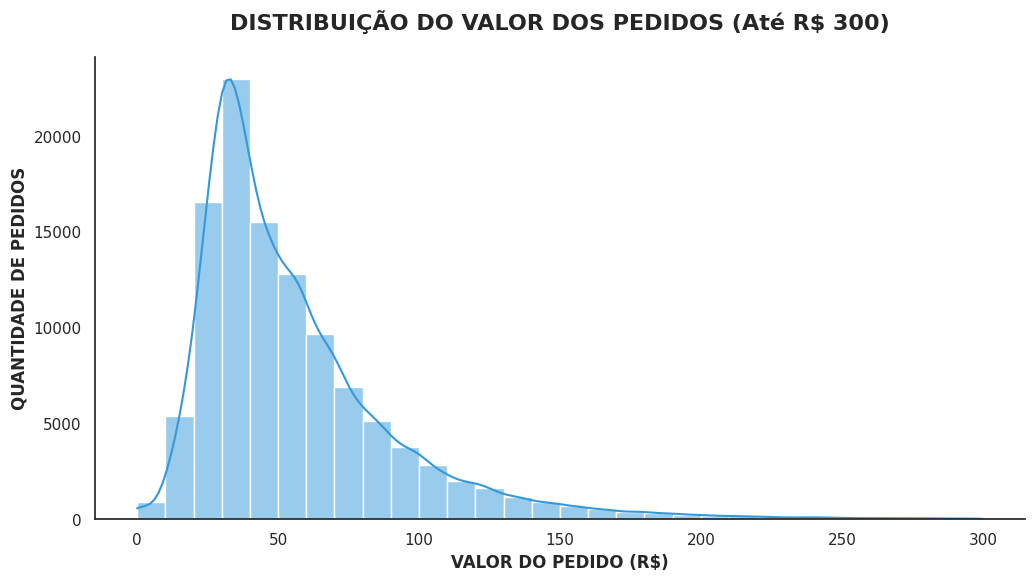

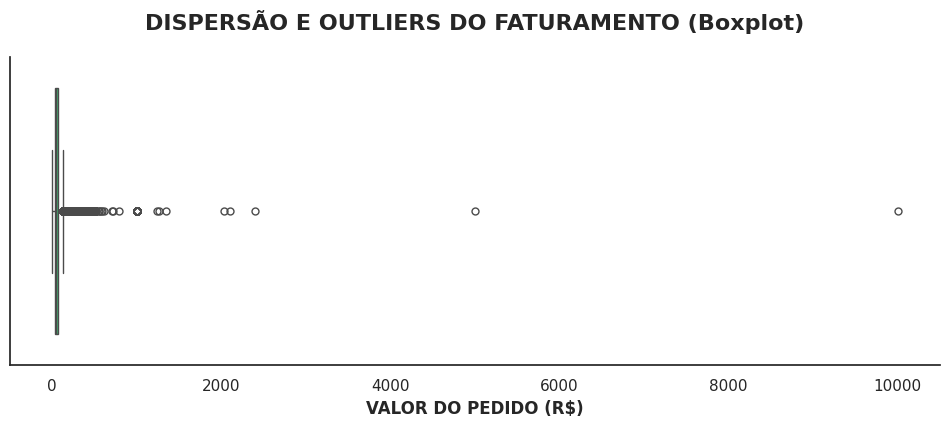

/tmp/ipykernel_3161/24026333.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax1 = sns.barplot(x=periodos, y=pedidos_periodo, palette='Blues_d')


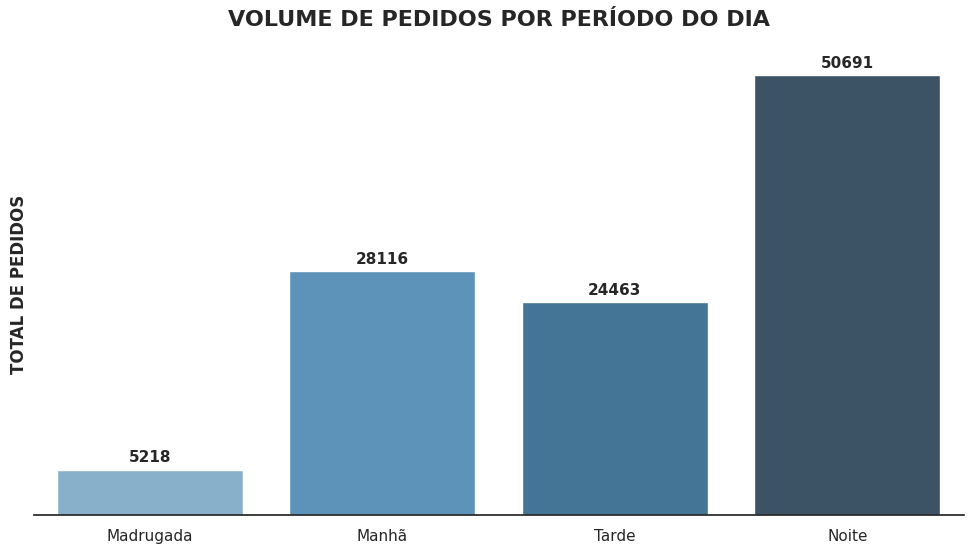

/tmp/ipykernel_3161/24026333.py:66: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax2 = sns.barplot(x=dias, y=pedidos_dia, palette='viridis')


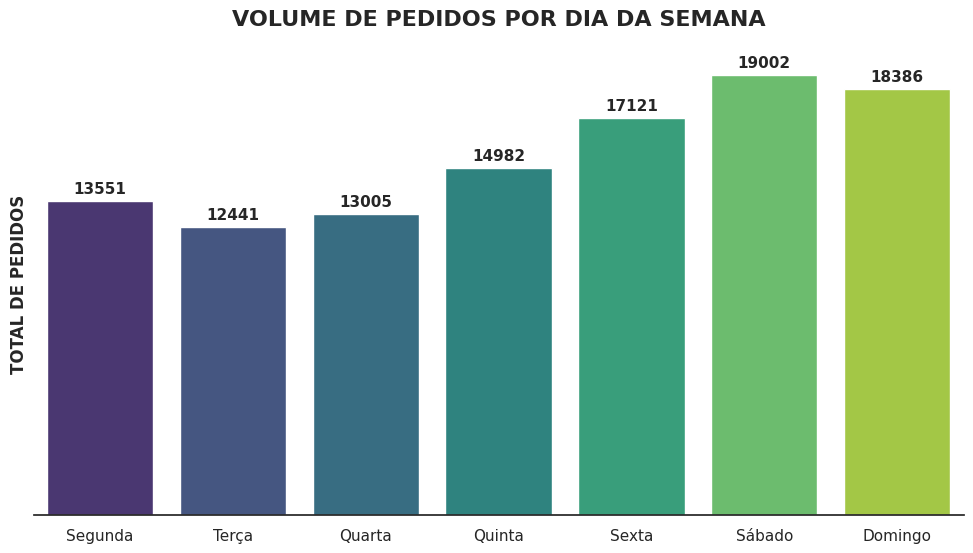

In [52]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Configuração de Estilo
sns.set_theme(style="white")
plt.rcParams['figure.figsize'] = [12, 6]

# --- DADOS DE APOIO (Caso não estejam carregados) ---
dias = ['Segunda','Terça','Quarta','Quinta','Sexta','Sábado','Domingo']
pedidos_dia = [13551, 12441, 13005, 14982, 17121, 19002, 18386]

periodos = ['Madrugada', 'Manhã', 'Tarde', 'Noite']
pedidos_periodo = [5218, 28116, 24463, 50691]

# --- FUNÇÃO PARA ADICIONAR OS NÚMEROS EM CIMA DAS BARRAS ---
def add_value_labels(ax):
    for p in ax.patches:
        ax.annotate(format(p.get_height(), '.0f'),
                   (p.get_x() + p.get_width() / 2., p.get_height()),
                   ha = 'center', va = 'center',
                   xytext = (0, 9),
                   textcoords = 'offset points',
                   fontsize=11, fontweight='bold')

# ==============================================================================
# A) HISTOGRAMA
# ==============================================================================
plt.figure()
sns.histplot(df_v['totalamount'][df_v['totalamount'] < 300], bins=30, kde=True, color='#3498db')
plt.title('DISTRIBUIÇÃO DO VALOR DOS PEDIDOS (Até R$ 300)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('VALOR DO PEDIDO (R$)', fontweight='bold')
plt.ylabel('QUANTIDADE DE PEDIDOS', fontweight='bold')
sns.despine()
plt.savefig('grafico_histograma.png', dpi=300, bbox_inches='tight')
plt.show()

# ==============================================================================
# B) BOXPLOT (IMPORTANTE PARA ANÁLISE INFERENCIAL)
# ==============================================================================
plt.figure(figsize=(12, 4))
sns.boxplot(x=df_v['totalamount'], color='#2ecc71', fliersize=5)
plt.title('DISPERSÃO E OUTLIERS DO FATURAMENTO (Boxplot)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('VALOR DO PEDIDO (R$)', fontweight='bold')
sns.despine()
plt.savefig('grafico_boxplot.png', dpi=300, bbox_inches='tight')
plt.show()

# ==============================================================================
# C) BARRAS - PERÍODO DO DIA (COM LEGENDAS/RÓTULOS)
# ==============================================================================
plt.figure()
ax1 = sns.barplot(x=periodos, y=pedidos_periodo, palette='Blues_d')
add_value_labels(ax1)
plt.title('VOLUME DE PEDIDOS POR PERÍODO DO DIA', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('TOTAL DE PEDIDOS', fontweight='bold')
sns.despine(left=True)
plt.yticks([]) # Remove eixo Y para focar no rótulo da barra
plt.savefig('grafico_periodos.png', dpi=300, bbox_inches='tight')
plt.show()

# ==============================================================================
# D) BARRAS - DIA DA SEMANA (COM LEGENDAS/RÓTULOS)
# ==============================================================================
plt.figure()
ax2 = sns.barplot(x=dias, y=pedidos_dia, palette='viridis')
add_value_labels(ax2)
plt.title('VOLUME DE PEDIDOS POR DIA DA SEMANA', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('TOTAL DE PEDIDOS', fontweight='bold')
sns.despine(left=True)
plt.yticks([]) # Remove eixo Y
plt.savefig('grafico_dias_semana.png', dpi=300, bbox_inches='tight')
plt.show()

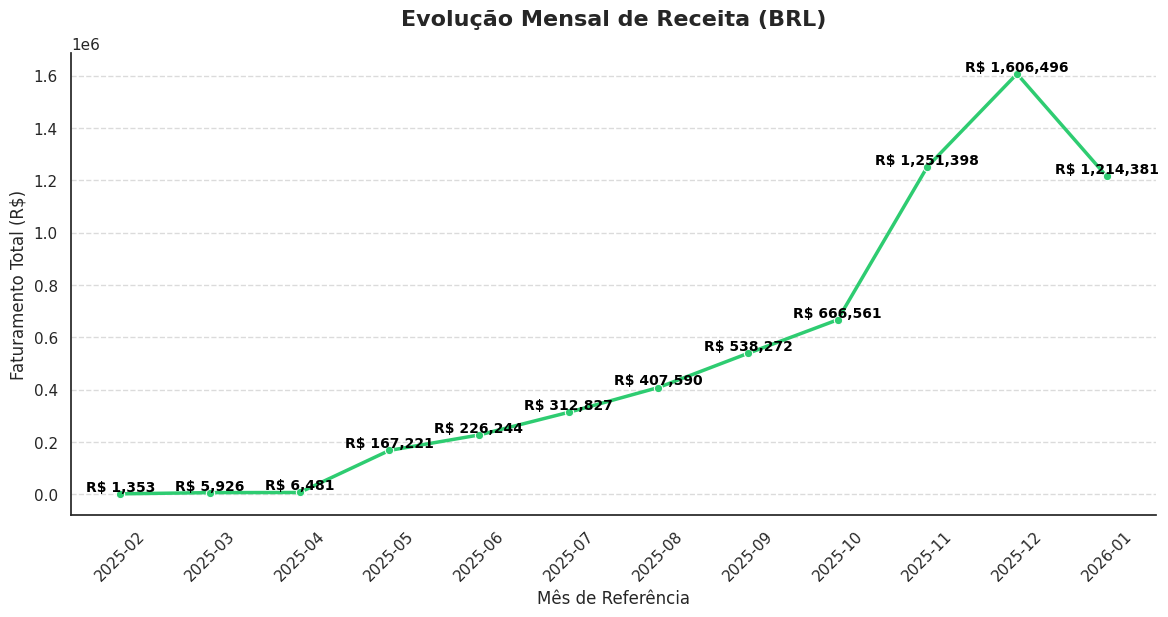

=== TABELA DE EVOLUÇÃO MENSAL ===


,Mes_Ano,Receita_Total,Qtd_Pedidos
0,2025-02,1.352550e+03,16
1,2025-03,5.925810e+03,54
2,2025-04,6.480740e+03,69
3,2025-05,1.672214e+05,2799
4,2025-06,2.262442e+05,3683
5,2025-07,3.128270e+05,4877
6,2025-08,4.075898e+05,7060
7,2025-09,5.382716e+05,9476
8,2025-10,6.665609e+05,12446
9,2025-11,1.251398e+06,22493


In [53]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# --- 1. PREPARAÇÃO DA SÉRIE TEMPORAL ---
# Criando a coluna de Mês/Ano para agrupamento
df_v['mes_ano'] = df_v['createdat'].dt.to_period('M').astype(str)

# Agrupando Receita Total e Quantidade de Pedidos por mês
df_evolucao = df_v.groupby('mes_ano').agg({
    'totalamount': 'sum',
    'id': 'count'
}).reset_index()

df_evolucao.columns = ['Mes_Ano', 'Receita_Total', 'Qtd_Pedidos']

# --- 2. GERAÇÃO DO GRÁFICO DE LINHAS ---
plt.figure(figsize=(14, 6))
ax = sns.lineplot(data=df_evolucao, x='Mes_Ano', y='Receita_Total', marker='o', color='#2ecc71', linewidth=2.5)

# Adicionando Rótulos de Valor (R$) em cada ponto
for x, y in zip(df_evolucao['Mes_Ano'], df_evolucao['Receita_Total']):
    plt.text(x, y, f'R$ {y:,.0f}', color='black', ha='center', va='bottom', fontweight='bold', fontsize=10)

# Estilização
plt.title("Evolução Mensal de Receita (BRL)", fontsize=16, fontweight='bold', pad=20)
plt.xlabel("Mês de Referência", fontsize=12)
plt.ylabel("Faturamento Total (R$)", fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
sns.despine()

# Salvar para o relatório
plt.savefig('grafico_evolucao_receita.png', dpi=300, bbox_inches='tight')
plt.show()

# Exibir tabela para conferência dos valores
print("=== TABELA DE EVOLUÇÃO MENSAL ===")
display(df_evolucao)

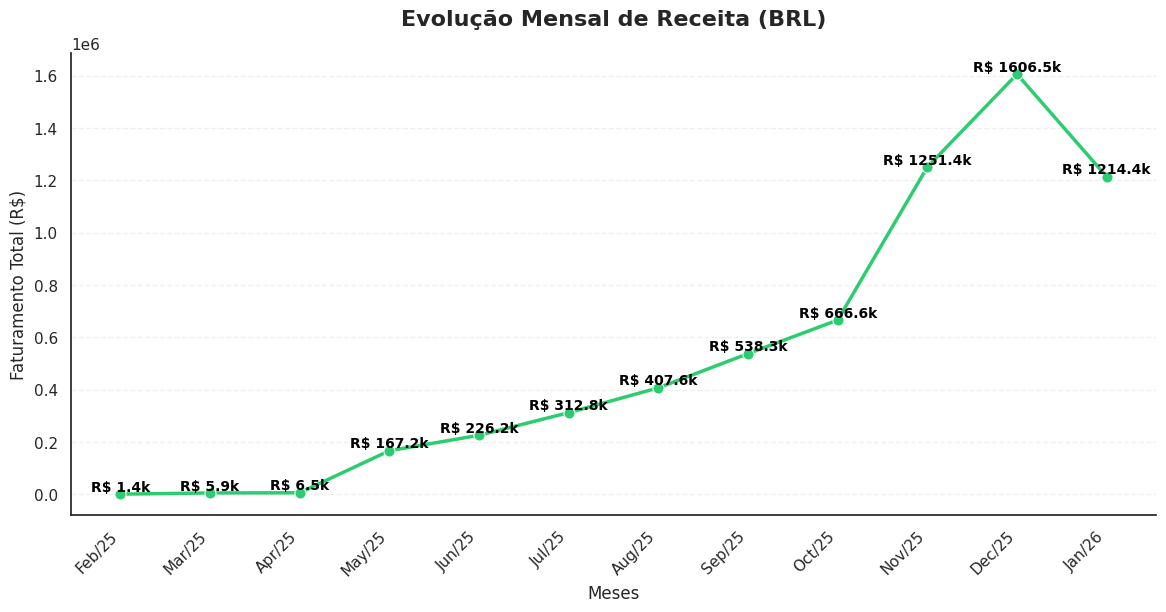

In [54]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# --- 1. PREPARAÇÃO DOS DADOS (AGRUPAMENTO MENSAL) ---
# Agrupando e garantindo que o índice seja o primeiro dia do mês
df_mensal = df_v.resample('MS', on='createdat')['totalamount'].sum().reset_index()

# CRIANDO A COLUNA FORMATADA (Ex: "Jan/24", "Fev/24")
# %b é o mês abreviado, %y é o ano com 2 dígitos
df_mensal['mes_rotulo'] = df_mensal['createdat'].dt.strftime('%b/%y')

# --- 2. GERAÇÃO DO GRÁFICO ---
plt.figure(figsize=(14, 6))

# Note que usamos 'mes_rotulo' no eixo X para forçar o texto
ax = sns.lineplot(data=df_mensal, x='mes_rotulo', y='totalamount',
                 marker='o', color='#2ecc71', linewidth=2.5, markersize=8)

# --- 3. AJUSTES FINAIS ---
# Rotação para garantir que não encoste um no outro
plt.xticks(rotation=45, ha='right', fontsize=11, fontweight='500')

# Rótulos de Valor (R$ em 'k' para ficar limpo)
for x, y in zip(df_mensal['mes_rotulo'], df_mensal['totalamount']):
    plt.text(x, y, f'R$ {y/1000:.1f}k', color='black',
             ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.title("Evolução Mensal de Receita (BRL)", fontsize=16, fontweight='bold', pad=20)
plt.ylabel("Faturamento Total (R$)", fontsize=12)
plt.xlabel("Meses", fontsize=12)
sns.despine()
plt.grid(axis='y', linestyle='--', alpha=0.3)

# Salvar
plt.savefig('grafico_evolucao_final.png', dpi=300, bbox_inches='tight')
plt.show()

--- TABELA DE INDICADORES GERADA ---


,Indicador,Valor
0,Total de Clientes,49351.00
1,Total de Pedidos,111599.00
2,Clientes Novos (<30d),7887.00
3,Clientes Ativos (<30d),13602.00
4,Clientes em Alerta (30-60d),12191.00
5,Clientes Sumidos (>90d),13314.00
6,Clientes Recuperados,2778.00
7,Ticket Médio (R$),57.39
8,Baixo Ticket (<50),61468.00
9,Médio Ticket (50-100),38427.00


/tmp/ipykernel_3161/2236363184.py:75: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax1 = sns.barplot(data=df_v.groupby('periodo', observed=True).size().reset_index(name='Total'),


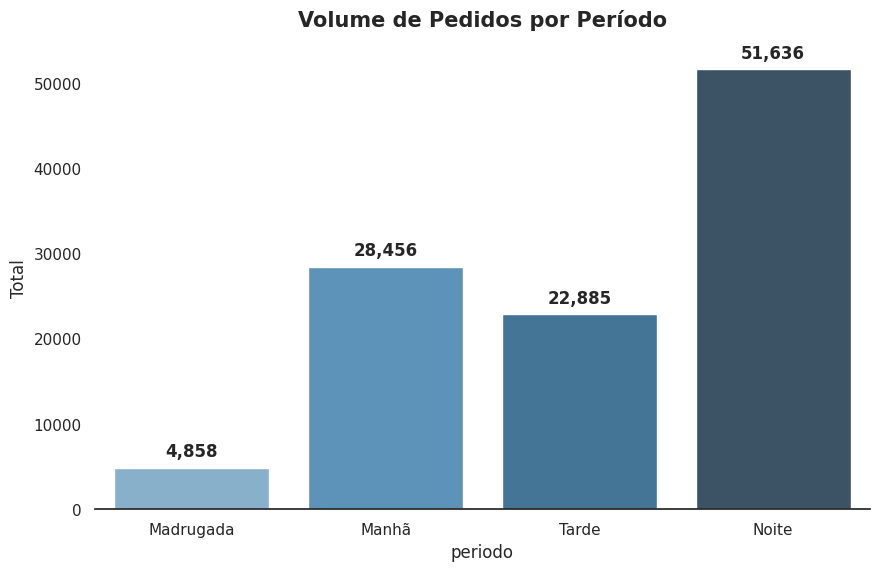

/tmp/ipykernel_3161/2236363184.py:88: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax2 = sns.barplot(data=df_dias, x='dia_semana', y='Total', palette='viridis')


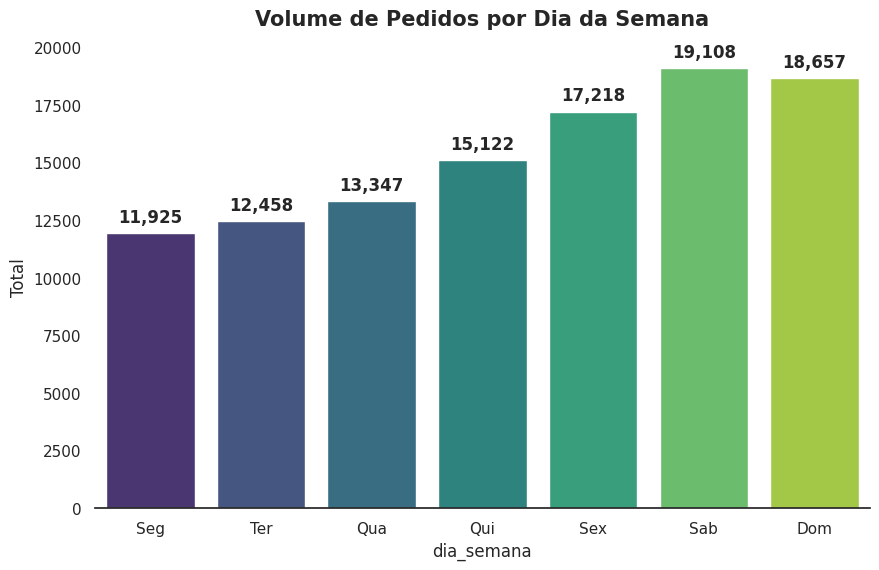

✅ Processamento concluído! Ficheiros 'tabela_indicadores_crisp.csv', 'grafico_periodos.png' e 'grafico_semanal.png' prontos.


In [57]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from datetime import timedelta
import os

# --- 1. CONFIGURAÇÕES VISUAIS ---
sns.set_theme(style="white")
plt.rcParams['figure.figsize'] = [12, 6]

# --- 2. PREPARAÇÃO DOS DADOS (DATA PREPARATION) ---
# Clonando para não afetar o original carregado no início do Colab
df_v = df_orders.copy()

# TRATAMENTO DE DATAS (AJUSTADO PARA EVITAR TYPEERROR)
# Usamos utc=True para padronizar e depois convertemos para o fuso de SP
df_v['createdat'] = (pd.to_datetime(df_v['createdat'], errors='coerce', utc=True)
                     .dt.tz_convert('America/Sao_Paulo')
                     .dt.tz_localize(None))

# Filtro de Status Operacionais Válidos (Conforme sua regra de negócio)
status_validos = [1, 15, 16, 33, 34, 35, 37, 38]
df_v = df_v[df_v['status'].isin(status_validos)].copy()

# Referência de "Hoje" baseada no último pedido da base
hoje = df_v['createdat'].max()

# --- 3. ENGENHARIA DE ATRIBUTOS (CRM & RECORRÊNCIA) ---
# Cálculo de Recência por Cliente
df_recencia = df_v.groupby('customerid')['createdat'].max().reset_index()
df_recencia['dias_parado'] = (hoje - df_recencia['createdat']).dt.days

# Lógica de Clientes Recuperados (Gap > 30 dias e comprou nos últimos 30 dias)
df_v = df_v.sort_values(['customerid', 'createdat'])
df_v['gap'] = df_v.groupby('customerid')['createdat'].diff().dt.days
ids_recuperados = df_v[(df_v['gap'] > 30) & (df_v['createdat'] >= hoje - timedelta(days=30))]['customerid'].unique()

# --- 4. GERAÇÃO DOS 12 INDICADORES (KPIs) ---
indicadores = {
    "Total de Clientes": df_v['customerid'].nunique(),
    "Total de Pedidos": len(df_v),
    "Clientes Novos (<30d)": df_v.groupby('customerid')['createdat'].min().gt(hoje - timedelta(days=30)).sum(),
    "Clientes Ativos (<30d)": (df_recencia['dias_parado'] < 30).sum(),
    "Clientes em Alerta (30-60d)": df_recencia['dias_parado'].between(30, 59).sum(),
    "Clientes Sumidos (>90d)": (df_recencia['dias_parado'] >= 90).sum(),
    "Clientes Recuperados": len(ids_recuperados),
    "Ticket Médio (R$)": round(df_v['totalamount'].mean(), 2),
    "Baixo Ticket (<50)": (df_v['totalamount'] < 50).sum(),
    "Médio Ticket (50-100)": df_v['totalamount'].between(50, 100).sum(),
    "Alto Ticket (>100)": (df_v['totalamount'] > 100).sum()
}

df_kpi = pd.DataFrame(list(indicadores.items()), columns=['Indicador', 'Valor'])

# Exportação para CSV
df_kpi.to_csv('tabela_indicadores_crisp.csv', index=False)
print("--- TABELA DE INDICADORES GERADA ---")
display(df_kpi)

# --- 5. VISUALIZAÇÃO DOS DADOS (EDA) ---
def finalizar_plot(ax, titulo, nome_arq):
    for p in ax.patches:
        ax.annotate(f'{int(p.get_height()):,}', (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='bottom', xytext=(0, 5), textcoords='offset points', fontweight='bold')
    plt.title(titulo, fontsize=15, fontweight='bold', pad=15)
    sns.despine(left=True)
    plt.savefig(nome_arq, dpi=300, bbox_inches='tight')
    plt.show()

# Gráfico 1: Volume por Período do Dia
df_v['hora'] = df_v['createdat'].dt.hour
df_v['periodo'] = pd.cut(df_v['hora'], bins=[-1, 5, 11, 17, 23], labels=['Madrugada','Manhã','Tarde','Noite'])

plt.figure(figsize=(10, 6))
ax1 = sns.barplot(data=df_v.groupby('periodo', observed=True).size().reset_index(name='Total'),
                  x='periodo', y='Total', palette='Blues_d')
finalizar_plot(ax1, "Volume de Pedidos por Período", "grafico_periodos.png")

# Gráfico 2: Volume por Dia da Semana (Ordenado)
df_v['dia_semana'] = df_v['createdat'].dt.day_name()
ordem_dias = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
traducao_dias = {'Monday': 'Seg', 'Tuesday': 'Ter', 'Wednesday': 'Qua', 'Thursday': 'Qui', 'Friday': 'Sex', 'Saturday': 'Sab', 'Sunday': 'Dom'}

df_dias = df_v.groupby('dia_semana').size().reindex(ordem_dias).reset_index(name='Total')
df_dias['dia_semana'] = df_dias['dia_semana'].map(traducao_dias)

plt.figure(figsize=(10, 6))
ax2 = sns.barplot(data=df_dias, x='dia_semana', y='Total', palette='viridis')
finalizar_plot(ax2, "Volume de Pedidos por Dia da Semana", "grafico_semanal.png")

print("✅ Processamento concluído! Ficheiros 'tabela_indicadores_crisp.csv', 'grafico_periodos.png' e 'grafico_semanal.png' prontos.")

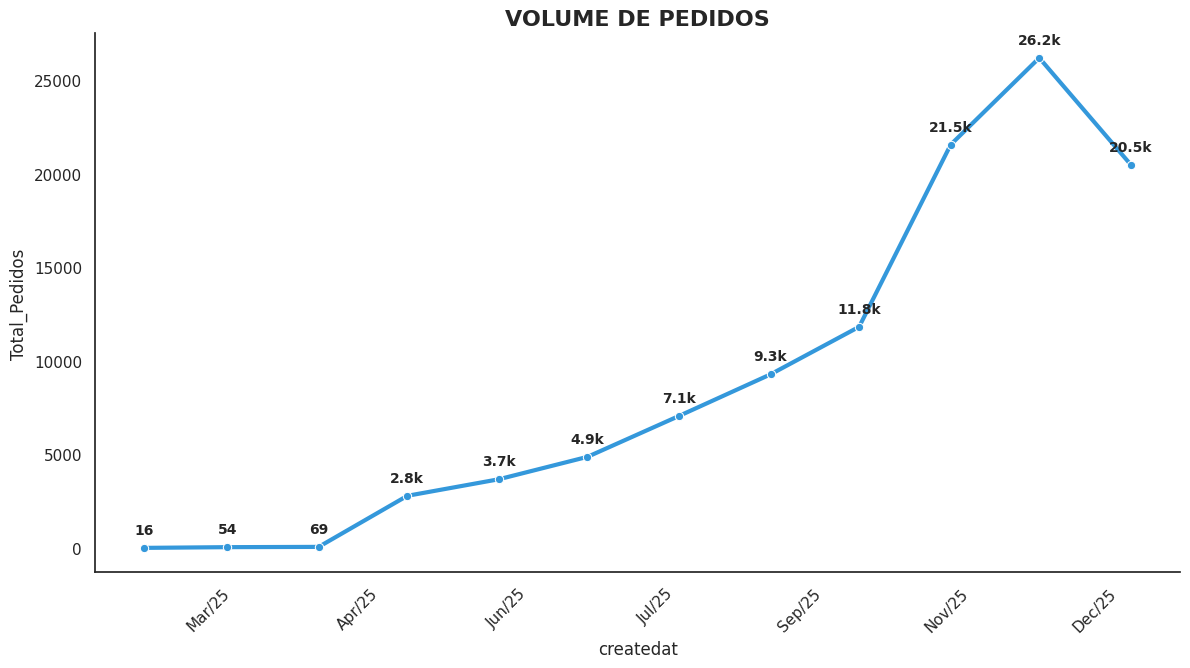

✅ Arquivo 'indicadores_cannoli_final.csv' gerado com ponto decimal!


In [60]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as ticker

# --- 1. CONFIGURAÇÃO DE EXIBIÇÃO NO PANDAS ---
# Isso garante que o display do Colab mostre ponto
pd.options.display.float_format = '{:.2f}'.format

# --- 2. GERANDO O GRÁFICO COM FORMATAÇÃO DE PONTO ---
fig, ax = plt.subplots(figsize=(14, 7))

sns.lineplot(data=df_volume, x='createdat', y='Total_Pedidos',
             marker='o', color='#3498db', linewidth=3, ax=ax)

# Rótulos de Valores com PONTO (US Pattern)
for x, y in zip(df_volume['createdat'], df_volume['Total_Pedidos']):
    # O Python usa ponto por padrão, aqui forçamos 1 casa decimal
    label = "{:.1f}k".format(y/1000) if y >= 1000 else "{:.0f}".format(y)
    ax.annotate(label, (x, y), textcoords="offset points",
                xytext=(0,10), ha='center', fontsize=10, fontweight='bold')

# --- 3. FORMATAÇÃO DO EIXO X (nbins corrigido) ---
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b/%y'))
ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=8))
plt.xticks(rotation=45, ha='right')

plt.title("VOLUME DE PEDIDOS", fontsize=16, fontweight='bold')
sns.despine()
plt.show()

# --- 4. EXPORTANDO O CSV COM PONTO (IMPORTANTE) ---
# Ao salvar, garantimos que o separador decimal seja ponto e o de colunas seja vírgula
df_kpi.to_csv('indicadores_cannoli_final.csv', index=False, sep=',', decimal='.')

print("✅ Arquivo 'indicadores_cannoli_final.csv' gerado com ponto decimal!")

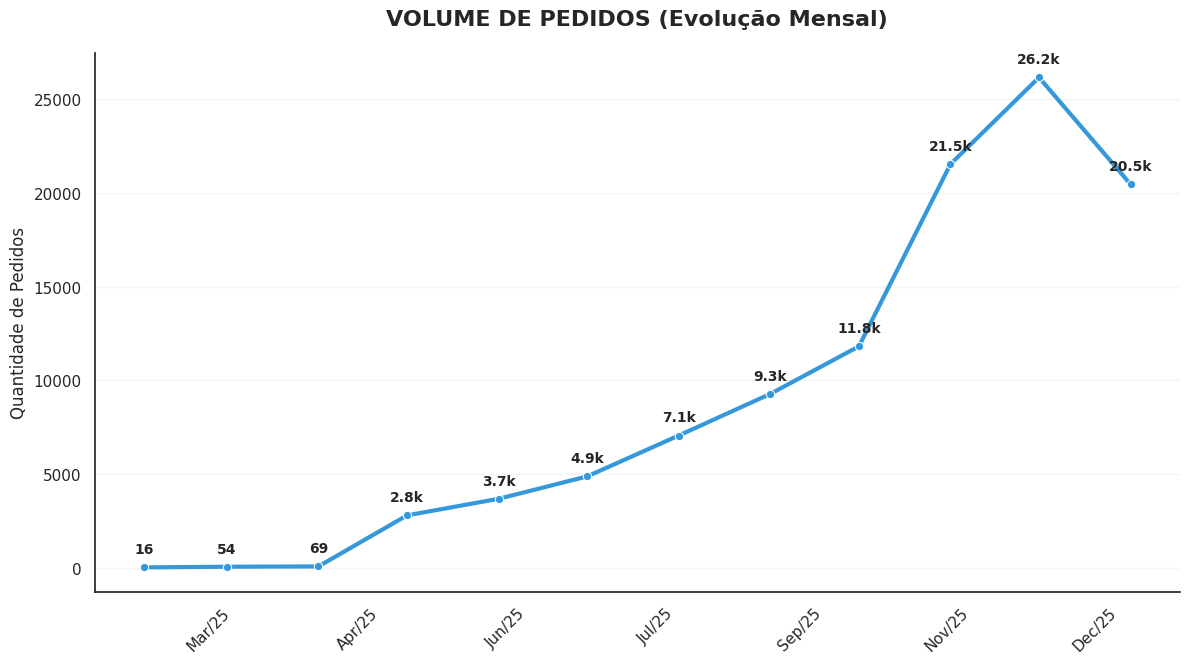

In [59]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as ticker

# --- 1. PREPARAÇÃO ---
df_volume = df_v.resample('MS', on='createdat').size().reset_index(name='Total_Pedidos')

# --- 2. GERAÇÃO DO GRÁFICO ---
fig, ax = plt.subplots(figsize=(14, 7))

sns.lineplot(data=df_volume, x='createdat', y='Total_Pedidos',
             marker='o', color='#3498db', linewidth=3, ax=ax)

# --- 3. RÓTULOS COM PONTO (Ex: 3.5k) ---
for x, y in zip(df_volume['createdat'], df_volume['Total_Pedidos']):
    label = "{:.1f}k".format(y/1000) if y >= 1000 else "{:.0f}".format(y)
    ax.annotate(label, (x, y), textcoords="offset points",
                xytext=(0,10), ha='center', fontsize=10, fontweight='bold')

# --- 4. FORMATAÇÃO DO EIXO X (DATAS) ---
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b/%y'))
ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=8))
plt.xticks(rotation=45, ha='right')

# --- 5. LIMPANDO O RODAPÉ (REMOVENDO 'createdat') ---
plt.xlabel(None) # <--- ISSO TIRA O NOME DO RODAPÉ
plt.ylabel("Quantidade de Pedidos", fontsize=12)
plt.title("VOLUME DE PEDIDOS (Evolução Mensal)", fontsize=16, fontweight='bold', pad=20)

sns.despine()
plt.grid(axis='y', alpha=0.2)
plt.show()

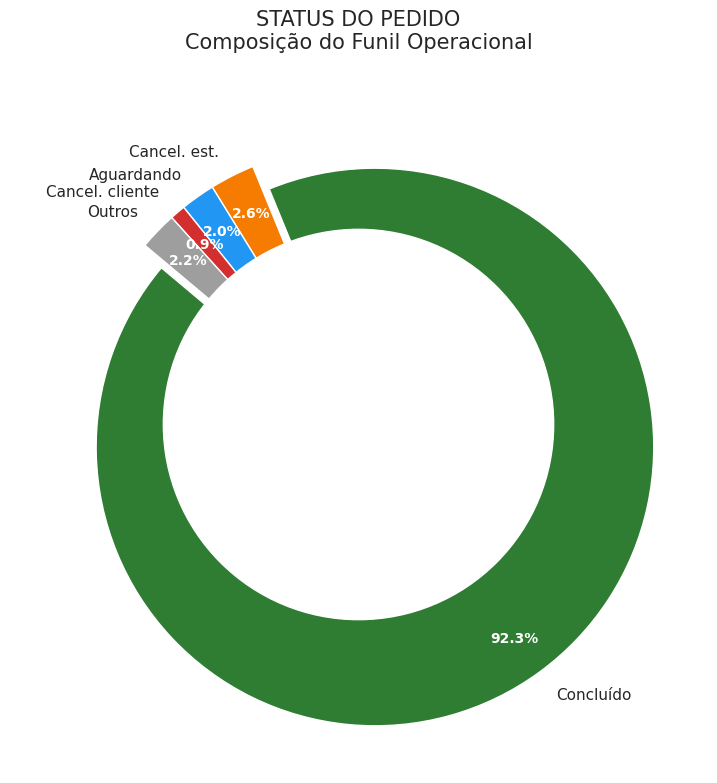

In [61]:
import matplotlib.pyplot as plt

# Dados baseados na sua imagem de composição de funil
labels = ['Concluído', 'Cancel. est.', 'Aguardando', 'Cancel. cliente', 'Outros']
sizes = [92.3, 2.6, 2.0, 0.9, 2.2]
colors = ['#2e7d32', '#f57c00', '#2196f3', '#d32f2f', '#9e9e9e']
explode = (0.1, 0, 0, 0, 0)  # "Explode" a fatia de Concluídos para destaque

fig, ax = plt.subplots(figsize=(8, 8))

# Criando o gráfico de pizza
wedges, texts, autotexts = ax.pie(sizes, explode=explode, labels=labels, autopct='%1.1f%%',
                                  startangle=140, colors=colors, pctdistance=0.85)

# Desenhando o círculo central (o que transforma a pizza em rosca)
centre_circle = plt.Circle((0,0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

# Ajustando o texto
plt.setp(autotexts, size=10, weight="bold", color="white")
ax.set_title("STATUS DO PEDIDO\nComposição do Funil Operacional", fontsize=15, pad=20)

plt.tight_layout()
plt.show()

/tmp/ipykernel_3161/655915598.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=df_status, x='Percentual', y='Status', palette=cores)


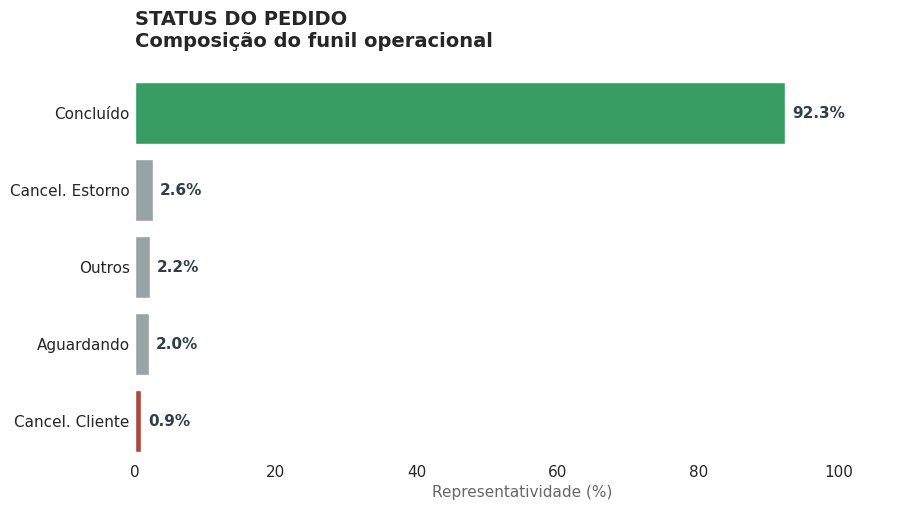

In [62]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# --- 1. DADOS (Usando os valores reais do seu projeto) ---
dados = {
    'Concluído': 92.3,
    'Cancel. Estorno': 2.6,
    'Aguardando': 2.0,
    'Outros': 2.2,
    'Cancel. Cliente': 0.9
}
df_status = pd.Series(dados).sort_values(ascending=False).reset_index()
df_status.columns = ['Status', 'Percentual']

# --- 2. GERAÇÃO DO GRÁFICO ---
plt.figure(figsize=(10, 5))
cores = ['#27ae60', '#95a5a6', '#95a5a6', '#95a5a6', '#c0392b'] # Verde para sucesso, Vermelho para erro, Cinza para o resto

ax = sns.barplot(data=df_status, x='Percentual', y='Status', palette=cores)

# --- 3. RÓTULOS COM PONTO DECIMAL (Na ponta das barras) ---
for i, p in enumerate(ax.patches):
    width = p.get_width()
    ax.text(width + 1, p.get_y() + p.get_height()/2,
            f'{width:.1f}%', # PONTO DECIMAL FORÇADO
            va='center', fontweight='bold', fontsize=11, color='#2c3e50')

# --- 4. LIMPANDO TUDO (REMOVENDO O 'createdat' E OUTROS) ---
plt.title("STATUS DO PEDIDO\nComposição do funil operacional", loc='left', fontsize=14, fontweight='bold', pad=20)
plt.xlabel("Representatividade (%)", fontsize=11, alpha=0.7)
plt.ylabel(None) # <--- ISSO TIRA O NOME DA COLUNA DA LATERAL
plt.xlim(0, 110) # Espaço para o texto não cortar

# Remove as bordas do gráfico para ficar "Clean"
sns.despine(left=True, bottom=True)
ax.tick_params(axis='both', which='both', length=0) # Tira os tracinhos dos eixos

plt.savefig('status_barras_limpas.png', dpi=300, bbox_inches='tight')
plt.show()

/tmp/ipykernel_3161/1676889435.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax1 = sns.barplot(data=df_dias, x='Qtd_Pedidos', y='Dia_Semana', palette=cores_kpi)


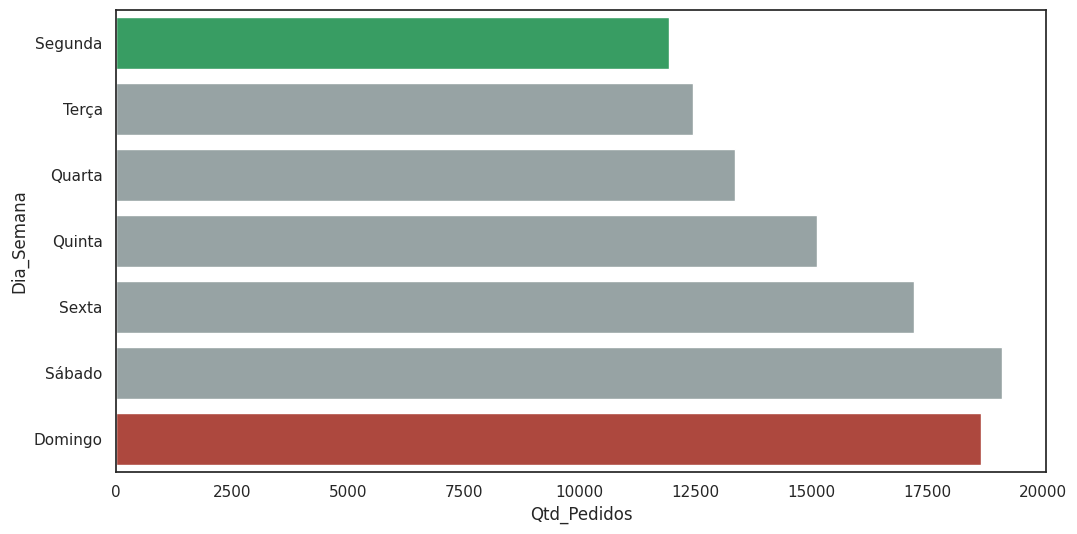

In [63]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# --- 1. CONFIGURAÇÃO VISUAL GERAL (PADRÃO CC) ---
sns.set_theme(style="white")
# Define as cores principais do Dashboard
# Verde (Sucesso/Pico), Vermelho (Alerta/Baixo volume), Cinza (Padrão)
cores_kpi = ['#27ae60', '#95a5a6', '#95a5a6', '#95a5a6', '#95a5a6', '#95a5a6', '#c0392b']
cores_periodo = ['#c0392b', '#95a5a6', '#95a5a6', '#27ae60'] # Madrugada baixa, Noite alta

# --- 2. GRÁFICO 1: VOLUME POR DIA DA SEMANA (Barras Horizontais) ---
# df_v já contém o campo 'createdat' tratado

# Criando coluna e agrupando
df_v['dia_semana'] = df_v['createdat'].dt.day_name()
df_dias = df_v['dia_semana'].value_counts().reset_index()
df_dias.columns = ['Dia_Semana', 'Qtd_Pedidos']

# Tradução dos dias e reordenação (Segunda -> Domingo)
traducao_dias = {
    'Monday': 'Segunda', 'Tuesday': 'Terça', 'Wednesday': 'Quarta',
    'Thursday': 'Quinta', 'Friday': 'Sexta', 'Saturday': 'Sábado', 'Sunday': 'Domingo'
}
df_dias['Dia_Semana'] = df_dias['Dia_Semana'].map(traducao_dias)
df_dias['Ordem'] = df_dias['Dia_Semana'].map({
    'Segunda': 0, 'Terça': 1, 'Quarta': 2, 'Quinta': 3, 'Sexta': 4, 'Sábado': 5, 'Domingo': 6
})
df_dias = df_dias.sort_values('Ordem')

# Geração do Gráfico
plt.figure(figsize=(12, 6))
ax1 = sns.barplot(data=df_dias, x='Qtd_Pedidos', y='Dia_Semana', palette=cores_kpi)

# Rótulos de Volume

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [64]:
import shutil

# Defina a pasta de destino no seu Drive
destino = '/content/drive/MyDrive/DADOS_CANNOLI/RESULTADOS_PROJETO/'

# Criar a pasta se ela não existir
if not os.path.exists(destino):
    os.makedirs(destino)

# Lista de arquivos que você gerou no script anterior
arquivos_para_salvar = [
    'tabela_indicadores_crisp.csv',
    'grafico_periodos.png',
    'grafico_semanal.png'
]

# Copiar cada arquivo para o Drive
for arq in arquivos_para_salvar:
    if os.path.exists(arq):
        shutil.copy(arq, destino + arq)
        print(f"✅ {arq} salvo com sucesso no Drive!")

✅ tabela_indicadores_crisp.csv salvo com sucesso no Drive!
✅ grafico_periodos.png salvo com sucesso no Drive!
✅ grafico_semanal.png salvo com sucesso no Drive!
